# Assignment 06 - Convolutional Neural Networks

### Due: Monday, Mar 2, before class

Name(s): Chang Min Bark<br>
Course: CSCI 357 - AI and Neural Networks<br>
Section: 01 - 1:00pm<br>
Semester: Spring 2026<br>
Instructor: Prof. King<br>

### References
* PyTorch Documentation: https://pytorch.org/docs/stable/index.html
* Weights & Biases Documentation: https://docs.wandb.ai/
* ...and a ton of Google and various AI interaction

# IMPORTANT: Colab Users

Yep, one more update to pyproject.toml! Replace your `dependencies` section to be the following:

```
dependencies = [
    "jupyter", "jupyterlab", "jupytext", "nbconvert", "ipython>=8.18.0", "ipykernel",
    "numpy", "pandas", "matplotlib",
    "scipy==1.13.1",
    "scikit-learn", "statsmodels",
    "torch", "torchvision", "torchaudio", "torchmetrics",
    "fastapi", "uvicorn", "gradio", "streamlit",
    "wandb", "tqdm",
    "kaggle", "kagglehub", "ucimlrepo"
]
```

The hard-coded `scipy` version addresses problems with `torchmetrics`.

One you do that, then you can resume this notebook.



In [1]:
import sys
import os
import time
from enum import Enum

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


In [2]:
from IPython.display import HTML, display

# Define CSS styles in a string variable for reuse across cells
css_styles = """
<style>
.todo-box {
    background-color: #fcf8e3;
    color: #000000;
    border-left: 6px solid #f0ad4e;
    padding: 10px;
    margin-bottom: 0;
}

.todo-box h3 {
    margin-top: 0;
}

.note-box {
    background-color: #d1ecf1;
    color: #000000;
    border-left: 6px solid #0c5460;
    padding: 10px;
    margin-bottom: 0;
}

.warning-box {
    background-color: #f8d7da;
    color: #000000;
    border-left: 6px solid #721c24;
    padding: 10px;
    margin-bottom: 0;
}

.section-box {
    background-color: rgb(125, 233, 150);
    color: #000000;
    border-left: 6px solid #155724;
    padding: 10px;
    margin-bottom: 0;
}
</style>
"""

display(HTML(css_styles))

In [3]:

def show_todo(todo_text):
    display(HTML(f"""
    <div class="todo-box">
    <h2>TODO: {todo_text}</h2>
    </div>
    """))

def show_note(note_text):
    display(HTML(f"""
    <div class="note-box">
    <h2>NOTE:</h2>
    <h4>{note_text}</h4>
    </div>
    """))

def show_warning(warning_text):
    display(HTML(f"""
    <div class="warning-box">
    <h2>WARNING:</h2>
    <h3>{warning_text}</h3>
    </div>
    """))

def show_section(section_text = ""):
    display(HTML(f"""
    <div class="section-box">
    <h1>{section_text}</h1>
    </div>
    """))

In [4]:
show_todo("Set Run Configuration")

# **Notebook Run Configuration**


As most of you have already discovered, you will frequently need to re-run your notebooks from scratch. As our models and data become larger and more complex, code cells that execute training can take a lot of time. Thus, once you have finish a cell that needs to train, you might want to just execute a few epochs, or perhaps NO epochs.

* Set the variable `RUN_TRAINING_MODE` below to one of the three enumerations, then write your code to conditionally set the number of epoch to run
* Set `DO_WANDB_LOGGING` to True when you are ready to log your results.

It's up to you to properly use these constants in your code to make it easy to rerun a notebook from scratch.

In [5]:
class RunTrainingMode(Enum):
    NONE = "NONE"
    QUICK = "QUICK"
    FULL = "FULL"

RUN_TRAINING_MODE = RunTrainingMode.FULL
DO_WANDB_LOGGING = True

# **Set up accelerator device**
> This code will create three variables
> * `cpu_device` - the default device all tensors are stored on when not explicity moving over to a GPU
> * `has_accel` - bool - `True` if you have a GPU, `False` otherwise.
> * `accel_device` - your accelerator device if you have a GPU, or set to `cpu_device` if no GPU is present to prevent exceptions if trying to run on a GPU when one is not available.


In [6]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: cuda


In [7]:
# Are we running from colab?
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Not running in Google Colab")

Running in Google Colab


In [8]:
show_todo("Set Project Path and Install Packages")

**TODO:** You need to set `project_path` to be the root path of your project. This needs to be done regardless if whether you are running from Colab or not. I included an example that works on my machine when running locally, and setting a Drive path when running from Google Colab.

In [9]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted successfully!")

    # DONE: Replace this with your Google Drive path to your project root. Below is an example:
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

    # Confirm the project_path exists, raise an error if not
    if not os.path.exists(PROJECT_PATH):
        raise FileNotFoundError(f"Project path NOT FOUND: \"{PROJECT_PATH}\"")
    else:
        print(f"Confirmed: Project path exists at \"{PROJECT_PATH}\"")
else:
    # DONE: Replace this with your project root.
    PROJECT_PATH = '/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp'

print(f"Project path: \"{PROJECT_PATH}\"")
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)
    sys.path.append(PROJECT_PATH + "/src")

# Ensure that the current working directory is PROJECT_PATH
if os.getcwd() != PROJECT_PATH:
    print(f"Changing working directory to project path: \"{PROJECT_PATH}\"")
    os.chdir(PROJECT_PATH)
else:
    print(f"Already in the correct working directory: \"{PROJECT_PATH}\"")

Mounted at /content/drive
Drive mounted successfully!
Confirmed: Project path exists at "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"
Changing working directory to project path: "/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp"


In [10]:
# Install any packages that are not part of the standard Google Colab environment
if IN_COLAB:
    # Install uv for fast installs (-q for quiet, -U for update)
    !pip install -qU uv
    # Install project dependencies and local code in editable mode,
    !uv pip install -e .
    print("Colab install commands are provided above; uncomment to run them.")
else:
    print("Running locally, assuming project dependencies installed in your local environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 110.4 MB/s eta 0:00:0000:0100:01
Using Python 3.12.12 environment at: /usr
Resolved 200 packages in 724ms                                       
Prepared 22 packages in 5.22s                                            
Uninstalled 4 packages in 74ms
Installed 22 packages in 66ms                               
 + asttokens==3.0.1
 + async-lru==2.2.0
 - cachetools==7.0.1
 + cachetools==6.2.6
 + executing==2.2.1
 - ipython==7.34.0
 + ipython==9.10.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + json5==0.13.0
 + jupyter==1.1.1
 + jupyter-lsp==2.3.0
 + jupyterlab==4.5.5
 + jupyterlab-server==2.28.0
 + lantern==0.1.0 (from file:///content/drive/My%20Drive/2026%20SS/CSCI357/csci357_2026sp)
 + lightning-utilities==0.15.3
 + pure-eval==0.2.3
 + pydeck==0.9.1
 - scipy==1.16.3
 + scipy==1.13.1
 + stack-data==0.6.3
 + streamlit==1.54.0
 + torchmetrics==1.8.2
 - traitlets==5.7.1
 + traitlets==5.14.3
 + ucimlrepo==0.0.7
Colab install co

In [11]:
# Once packages are installed, we can kill the kernel to force a restart. Just restart the kernel
if IN_COLAB:
    try:
        import lantern
        print(lantern.__file__)
        print("Success!")
    except Exception as e:
        print("Might need to restart your kernel.")
        # This will force the kernel to restart
        # import os
        # os.kill(os.getpid(), 9)

/content/drive/My Drive/2026 SS/CSCI357/csci357_2026sp/src/lantern/__init__.py
Success!


In [12]:
# This cell loads the 'autoreload' extension for IPython/Jupyter, which automatically reloads any modules
# you import whenever their code changes on disk. The first line loads the extension, and the second line
# sets autoreload to mode 2, which reloads all modules (except those excluded by %aimport) before each execution.
# This is especially useful when you're actively developing Python modules in separate files and want
# changes to be picked up immediately without restarting the notebook kernel.
# The 'imp' module is deprecated in Python 3.4 and removed in Python 3.12. Newer IPython/Jupyter versions
# of autoreload should not need it. Removing the install command.
#
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [13]:
import wandb

In [14]:
show_todo("Set W&B Configuration Variables")

# Set your identity variables for W&B!

Fill in the following variables below to ensure your data is properly logged to Weights & Biases

In [15]:
# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Chang Min Bark"
user_initials = "CMB"
user_id = "cb073"
user_email = "cb073@bucknell.edu"

In [16]:
show_section()

---
# Background

Last week you built a reusable engine: `ModelConfig`, `TrainerConfig`, `MLP_Model`, `Trainer`, checkpointing, early stopping, LR scheduling, and W&B sweeps. The engine was the infrastructure investment. This week we cash it in.

We are turning our attention to **Convolutional Neural Networks (CNNs)** -- the architecture that made deep learning undeniable for computer vision. Before you write a single line of CNN code, you need to understand *why* this architecture exists and *what assumptions it encodes*. That understanding starts with a concept called **inductive bias**.


## 1. Inductive Bias: Why Architecture Choices Are Assumptions

**Inductive bias** is the set of assumptions a model makes about the underlying structure of the data *before* it sees a single training example. In our context, think of it as **"Architectural Opinion."**

If you give someone a dataset of points and ask them to draw a line, they will usually draw a straight one. That is their inductive bias (Occam's razor, linearity). Without that bias, they might draw a squiggly line that hits every point perfectly but fails to predict the next one -- overfitting.

**A model without inductive bias cannot learn; it can only memorize.** To generalize to unseen data, the model *must* be biased toward certain types of solutions.

**The MLP's "Flat-World" View:**
A fully connected network (MLP) has an extremely weak inductive bias -- it only assumes the function is continuous. It treats a 28x28 image as a flat vector of 784 numbers. It has no concept that pixel (0, 0) is spatially close to pixel (0, 1) and unrelated to pixel (27, 27). To an MLP, an image of a sneaker and a random permutation of those same pixels are equally valid inputs. It has to learn *everything* from scratch, including the fact that neighboring pixels usually share colors. This is wildly inefficient.

**The CNN's "Spatial" View:**
A CNN encodes two powerful assumptions directly into its architecture:
1. **Locality:** Meaningful features are composed of neighboring pixels (edges, corners, textures).
2. **Translation Invariance:** A "cat ear" feature in the top-left corner is the same feature as a "cat ear" in the bottom-right.

Because the architecture *assumes* images have spatial structure, CNNs use dramatically fewer parameters (shared weights across spatial locations) and learn much faster. They don't need to re-learn what a "vertical edge" looks like at every single pixel location.

> **The engineer's rule of thumb:** Don't fight the data structure.
> * If your data is an image, use a CNN (spatial bias).
> * If your data is a time series, use an RNN (temporal bias -- Week 9).
> * If you use an MLP for images, you are trying to tighten a screw with a hammer. You *can* do it if the hammer is big enough (massive MLP), but it's bad engineering.

**Preview:** In the Lab, you will prove this empirically. A CNN with ~20K parameters will beat an MLP with ~400K parameters on FashionMNIST. The CNN's "opinion" about how pixels relate matches reality; the MLP's "opinion" is too broad to be useful.

Later in the semester we will see other architectural opinions: RNNs assume **sequential dependence** (recent past matters more than distant past -- Week 9), and Transformers assume **relationships over proximity** (any two parts of the input *might* be related regardless of distance -- Week 11). CNNs are one point on a spectrum of inductive biases, each suited to a different kind of data structure.


## 2. The Convolution Operation

At its core, a CNN applies a small sliding filter (called a **kernel**) across an input image. Technically, what PyTorch computes is **2D discrete cross-correlation**, not true mathematical convolution (which would flip the kernel first). The distinction rarely matters in practice because the network learns the kernel weights -- a flipped version of the "right" kernel is just as learnable as the original. But you should know the difference.

### What is a kernel? 

A kernel is a small matrix of weights used to convolve (or "slide") across an input image. The kernel is used to extract features from the input image. Here's a key concept to really understand: **Different kernels are used to extract different features from the input image.** If you get that, then you should have an "Aha!" moment! ML engineers get the best results through **feature engineering**. They spend a lot of time filtering and cleaning their data to ensure the notebook has a strong set of features so that the model can learn! This is **feature engineering**, and it's a key part of the ML engineer's duties. 

> If a kernel is nothing more than a feature extractor, you should be wondering - is it possible to learn a set of kernels that can extract the best set of features from the input? Yes! That's exactly what CNNs do. CNNs learn the best kernels to extract the features from the input image.

**A worked example:** Let's see how a simple kernel called a "vertical edge detector" works. Suppose we had a small 5x5 monochrome image. 0 is black, 1 is white. Our kernel is a 3x3 matrix. It has -1 on the left column and +1 on the right column, so it effectively computes (right − left) in each row and sums over rows. It therefore exhibits a strong "signal" only where there is a **vertical** change in intensity.

```
Input (5x5):  dark | bright    Kernel (3x3):   "right minus left"
┌─────────────────────┐           ┌───────────┐
│  0   0   1   1   1  │           │ -1  0  1  │
│  0   0   1   1   1  │           │ -1  0  1  │
│  0   0   1   1   1  │           │ -1  0  1  │
│  0   0   1   1   1  │           └───────────┘
│  0   0   1   1   1  │
└─────────────────────┘

When the kernel is over an edge (e.g. kernel centered at (1,1) on the input image) it sees:
  left column of kernel  → input values 0,0,0  →  (-1)(0)+(-1)(0)+(-1)(0) = 0
  right column of kernel → input values 1,1,1  →  (1)(1)+(1)(1)+(1)(1) = 3
  So the response is 3 — strong positive where the vertical edge sits.

When the kernel is entirely in black pixels or entirely in white pixels, left and right
columns see the same value, so (right − left) sums to 0 — no edge. Thus, the higher the value, the stronger the vertical edge!

Output (3x3):  a vertical line of high response exactly where the vertical edge is. This is a **feature map** -- a 2D spatial map showing *where in the image this particular feature appears*.
┌───────────┐
│  3  3  0  │
│  3  3  0  │
│  3  3  0  │
└───────────┘
```

### Visual example of a kernel in action
Let's visualize this with a an example using a different filter: a "ridge detector".
The center pixel is compared against its neighbors—the 
kernel heavily weights the center (8), subtracts the immediate neighbors (-1), and thus 
highlights places where the center differs from the surroundings (such as edges, corners, 
or isolated points). If all pixels are the same (flat color), they cancel out to 0. But at
an edge or isolated feature, the center stands out and the response pops.

Feature Map Shape: torch.Size([1, 1, 4, 5])


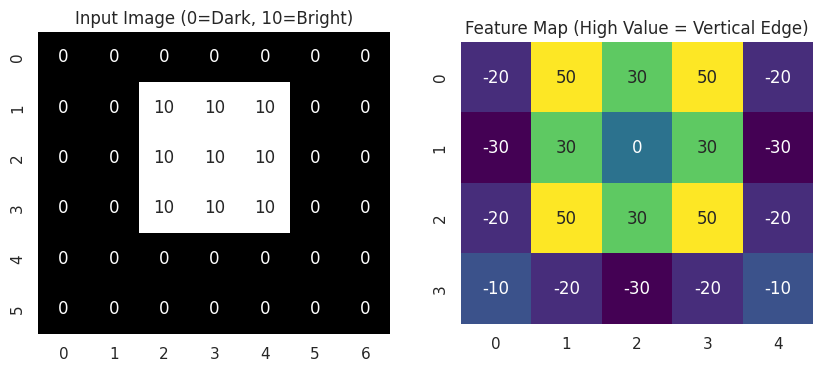

In [17]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# 1. THE IMAGE: A Solid Square (Block of 10s) in a field of 0s
image = torch.tensor([
    [0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 10., 10., 10., 0., 0.],
    [0., 0., 10., 10., 10., 0., 0.],
    [0., 0., 10., 10., 10., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 0., 0., 0., 0., 0.],
])
input_tensor = image.unsqueeze(0).unsqueeze(0)

# 2. THE KERNEL: "Ridge or edge detection - The center pixel is compared against its neighbors—the 
# kernel heavily weights the center (8), subtracts the immediate neighbors (-1), and thus 
# highlights places where the center differs from the surroundings (such as edges, corners, 
# or isolated points), i.e. any arbitrary edges or ridges! If all pixels are the same (flat color)
# they cancel out to 0. But at an edge or isolated feature, the center stands out and the response pops.
kernel = torch.tensor([
    [-1., -1., -1.],
    [-1.,  8., -1.],
    [-1., -1., -1.]
])

# We need to reshape our 2D kernel to the shape expected by PyTorch's conv2d:
# (out_channels, in_channels, kernel_height, kernel_width).
# Since we want a single output and input channel, we add two dimensions using unsqueeze:
weight = kernel.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 3, 3)

# 3. THE OPERATION: Apply Convolution
# We use functional API to manually pass our specific weight
feature_map = F.conv2d(input_tensor, weight, padding=0)

# 4. VISUALIZATION
print(f"Feature Map Shape: {feature_map.shape}") # Expect 4x5 

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot Input
sns.heatmap(image.numpy(), annot=True, fmt=".0f", cmap="gray", cbar=False, ax=axes[0], square=True)
axes[0].set_title("Input Image (0=Dark, 10=Bright)")

# Plot Output
# Squeeze removes batch/channel dims for plotting
sns.heatmap(feature_map.squeeze().numpy(), annot=True, fmt=".0f", cmap="viridis", cbar=False, ax=axes[1], square=True)
axes[1].set_title("Feature Map (High Value = Vertical Edge)")

plt.show()


Kernels are used extensively in computer vision and image processing to extract features from the input image. As you can imagine, we have quite a lot of hand-crafted kernel functions. Check out the following link for a list of hand-crafted kernel functions: https://en.wikipedia.org/wiki/Kernel_(image_processing)

### `torch.nn.Conv2d` Operation and Parameters

In the context of our **"Engine"**, `nn.Conv2d` is going to be the workhorse of the Convolutional Neural Network. It represets a layer of sliding window filters that learn spatial features.

The signature of the `Conv2d` operation is as follows:
```python
torch.nn.Conv2d(
    in_channels: int,
    out_channels: int,
    kernel_size: Union[int, Tuple[int, int]],
    stride: Union[int, Tuple[int, int]] = 1,
    padding: Union[str, int, Tuple[int, int]] = 0,
    dilation: Union[int, Tuple[int, int]] = 1,
    groups: int = 1,
    bias: bool = True
)
```

We won't deal with all of the parameters here, but let's look at the critical parameters:
* **`in_channels`**: The depth of the input volume.
  * *Examples:* `1` for grayscale (FashionMNIST), `3` for RGB (CIFAR-10), or `64` if it follows a previous layer with 64 filters.
* **`out_channels`**: The number of **filters** (kernels) the layer will learn. This determines the depth of the *output* volume.
  *  *Engineering Note:* This is the "width" of a convolutional layer. More channels = more diverse feature detection.
* **`kernel_size`**: The spatial dimensions of the sliding window.
  * *Common patterns:* `3` (3x3) is the modern standard. `1` (1x1) is used for channel-mixing without spatial aggregation. `5` or `7` are rare in modern architectures except maybe at the very first layer. This rare. 3x3 is the most common kernel size.
* **`stride`**: How far the kernel moves between positions.
  * `stride=1`: Processes every pixel location (dense).
  * `stride=2`: Skips every other pixel (downsamples spatial dims by ~2x).
* **`padding`**: Zero-padding added to the border of the input.
  * `padding=1` (with 3x3 kernel & stride 1): **Preserves spatial dimensions** ("Same" padding).
  * `padding=0`: **Valid** padding; output shrinks by `kernel_size - 1`.

### `conv2d` Output dimension formula
The `conv2d` operation is a mathematical operation that is used to convolve a kernel across an input image. It is a key operation in CNNs. The output dimension formula is used to calculate the output dimension of the convolution operation.

**Output dimension formula:** Given an input of spatial size $H_{in}$, kernel size $K$, padding $P$, and stride $S$:

$$H_{out} = \left\lfloor \frac{H_{in} - K + 2P}{S} \right\rfloor + 1$$

Quick exercises to internalize this:
* $H_{in}=28, K=3, P=1, S=1 \Rightarrow H_{out} = \lfloor(28 - 3 + 2)/1\rfloor + 1 = 28$ (same padding -- output matches input size)
* $H_{in}=28, K=3, P=0, S=1 \Rightarrow H_{out} = \lfloor(28 - 3 + 0)/1\rfloor + 1 = 26$ (valid padding -- output shrinks by 2)
* $H_{in}=28, K=3, P=1, S=2 \Rightarrow H_{out} = \lfloor(28 - 3 + 2)/2\rfloor + 1 = 14$ (stride 2 halves the spatial size)

### **Engineering Intuition**
* **Weight Sharing:** Unlike `nn.Linear`, which learns a unique weight for every input pixel, `Conv2d` learns a single kernel (e.g., 3x3 weights) and reuses it across the entire image. This is why CNNs are translation invariant.
* **Parameter Count:**
  * $ \text{Params} = (\text{kernel\_size}^2 \times C_{in} + 1) \times C_{out} $
  *   *Note:* The `+1` is for the bias term. Notice that parameters **do not depend on image height/width**, only on depth.

### **Parameter efficiency -- the core payoff**
A `Conv2d(in_channels=1, out_channels=32, kernel_size=3)` layer has $32 \times (1 \times 3 \times 3 + 1) = 320$ parameters. An equivalent `Linear(784, 32)` layer operating on a flattened 28x28 image has $784 \times 32 + 32 = 25{,}120$ parameters! That is **78x more parameters** for the same spatial coverage! This is the direct consequence of weight sharing -- the same 3x3 filter is applied at every spatial location.


In [18]:
show_note("If you can understand this section, you will be able to understand the rest of everything you need to understand conceptually about CNNs. A CNN's job is to learn the best kernels to extract the features from the input image.")
#

## 3. Kernels as Learned Feature Detectors

The vertical edge kernel in the worked example above was hand-designed. Classical computer vision is full of such hand-crafted kernels: the **Sobel operator** detects edges (horizontal and vertical), and the **Gaussian kernel** performs blurring. These were painstakingly engineered by domain experts over decades.

CNNs learn the same types of patterns, but **from data via backpropagation** rather than by hand. This is the core insight that explains why CNNs generalize: they discover the same low-level features a computer vision engineer would have hand-crafted (edges, blobs, textures), and higher layers compose them into increasingly abstract representations (corners, then parts, then objects).

When researchers visualized the first convolutional layer of a trained AlexNet (the model that won ImageNet in 2012; many attribute AlexNet for launching the deep learning revolution), the learned kernels looked remarkably like **Gabor filters** -- oriented edge detectors and color-blob detectors:

![Alexnet first layer visualized](https://aman.ai/cs231n/assets/visualization/4.jpg)

The network independently rediscovered what vision scientists had been studying for decades. This is not a coincidence; it is the direct result of the inductive bias we discussed above!

In the Challenges section, you will have the opportunity to extract and visualize your own CNN's learned filters and see this for yourself.


## 4. Feature Maps, Depth, and Receptive Fields

Each filter in a `Conv2d` layer produces one **feature map** -- a 2D spatial map showing *where in the image this particular feature appears*. If a layer has 32 filters, it produces 32 feature maps simultaneously, each detecting a different pattern.

**Tensor shape convention:** PyTorch uses the **NCHW** format for image tensors:
* $N$ = batch size
* $C$ = channels (1 for grayscale, 3 for RGB, or the number of feature maps from a previous layer)
* $H$ = height
* $W$ = width

So a batch of 64 grayscale FashionMNIST images is a tensor of shape $(64, 1, 28, 28)$, and after a `Conv2d(1, 32, 3, padding=1)` layer, the output is $(64, 32, 28, 28)$ -- 32 feature maps, each 28x28.

Let's see an example:

In [19]:
# Let's say we want to find 32 different features (edges, curves, etc.)
# Input: 1 image, 3 color channels (RGB), 32x32 size
rgb_image = torch.randn(1, 3, 32, 32)

# We need a kernel that handles 3 input channels and produces 32 output maps
# The kernel size effectively becomes (32, 3, 3, 3) -> 32 filters, each 3 deep, 3x3 spatial
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)

feature_maps = conv_layer(rgb_image)

print(f"Input image shape:   {rgb_image.shape}")    # [1, 3, 32, 32]
print(f"Feature maps shape:  {feature_maps.shape}") # [1, 32, 32, 32]
print(f"Total params:        {sum(p.numel() for p in conv_layer.parameters())}")
# Params = 32 * (3*3*3 + 1 bias) = 32 * 28 = 896

Input image shape:   torch.Size([1, 3, 32, 32])
Feature maps shape:  torch.Size([1, 32, 32, 32])
Total params:        896


In [20]:
show_warning("PyTorch expects NCHW. NumPy, OpenCV, and matplotlib typically use HWC (height, width, channels). This mismatch *will* cause bugs! When you see shape errors involving images, check your axis ordering first.")

**Advanced Topic:** 
The **receptive field** of a neuron is the region of the original input that influences its activation. A single 3x3 conv layer gives each output neuron a 3x3 receptive field. But stack *two* 3x3 conv layers, and each neuron in the second layer "sees" a 5x5 region of the original input (because it looks at a 3x3 window of first-layer outputs, each of which covers 3x3 of the original). This is the **VGGNet insight** (Simonyan, 2014): two stacked 3x3 convolutions have the same receptive field as a single 5x5 convolution, but with **fewer parameters** ($2 \times 3^2 = 18$ vs. $5^2 = 25$ per channel) and **two nonlinearities** instead of one, giving the network more expressive power. Oooo... ahhhh... very cool, right? You will be able to explore this architecture the challenges if you want!

Depth - it is not just about capacity -- it is about building increasingly abstract feature hierarchies. The first layer detects edges. The second layer detects corners and simple textures (compositions of edges). Deeper layers detect parts of objects, then whole objects. **Deep convolutional layers are just as important (if not *more* important) than the MLP layers 


## 5. Pooling

After convolution and ReLU, we have feature maps that indicate *where* edges or textures appear. Pooling **downsamples** these maps: within each small local window we replace several values with a single summary. That summary is computed **without any learned parameters** — it is a fixed rule (max or average). Pooling makes the representation smaller and more robust to small shifts.

**Max pooling** uses a sliding window (typically 2×2) with the same stride as the window size, so windows do not overlap. At each window we take the **maximum** of the four values and write that one number to the output. So the output is both smaller and "the strongest local response wins."

**Worked example — 2×2 max pool on a 4×4 feature map:**

```
Input (4×4), with 2×2 windows outlined:   Output (2×2):
┌───────────────────┐                     ┌──────┐
│  1   3  │  2   0  │  top-left: max      │ 4  5 │
│  4   2  │  1   5  │  = 4; top-right: 5  │ 2  4 │
├─────────┼─────────┤  bottom-left: 2;    └──────┘
│  0   1  │  3   2  │  bottom-right: 4
│  2   0  │  4   1  │
└───────────────────┘
```

Each output pixel is the max over one non-overlapping 2×2 block. No learned parameters — just a fixed downsampling rule.

**Why we use pooling — three roles:**

1. **Spatial reduction** — A 2×2 max pool halves height and width, so the number of activations drops by 4×. Later conv layers then operate on a coarser grid, which cuts computation and parameters. We only need fine spatial detail in early layers; by the time we pool, "there was an edge somewhere in this 2×2 region" is enough.

2. **Larger effective receptive field** — Each pooled value summarizes a 2×2 region of the previous layer. So the *next* conv layer's 3×3 filter is essentially "seeing" a larger patch of the *original* image. Pooling is what lets a relatively shallow stack of small convs still capture context over the whole image.

3. **Local translation invariance** — If a feature (e.g. an edge) moves by one pixel, it often still lies in the same 2×2 window, so the max (and thus the pooled output) may be unchanged. The network is biased toward caring that a feature *appeared* in a neighborhood, not its exact sub-pixel position. That matches vision: a cat's ear slightly shifted is still a cat's ear.

**Max vs average pooling:** Max pooling is standard in the middle of CNNs because we care about *detection* (e.g. "was there a strong response?") — the max value lets us retain strongest evidence in each window as we move forward. Average pooling blurs and smooths; one might think this is a better approach. Yet, it is less common between conv layers. **Global Average Pooling (GAP)** is different: it averages each *entire* feature map to a single number per channel, replacing the traditional `Flatten -> Linear` stack. ResNet and many modern architectures use GAP before the final classifier to reduce parameters and overfitting. You should know the term; and you could explore it in your challenges, but we will use standard 2×2 max pooling in this week's work.


## 6. The Canonical CNN Motif

Most CNNs follow a repeating block pattern:

```
[Conv2d -> ReLU -> MaxPool2d] x N  ->  Flatten  ->  Linear -> Dropout -> ... Linear
├──── feature extractor ────┤         ├──────── classifier head ────────┤
```

The **feature extractor** progressively transforms the raw image into a compact set of high-level feature maps. The **classifier head** maps those features to class logits. This separation is fundamental -- it is exactly what you will implement.

For reference, here is the function header for PyTorch's Conv2d:

```python
torch.nn.Conv2d(
    in_channels,      # Number of input channels (e.g., 1 for grayscale, 3 for RGB)
    out_channels,     # Number of output channels (i.e., number of learned filters)
    kernel_size,      # Size of the convolving kernel (e.g., 3 for 3x3)
    stride=1,         # Stride of the convolution (default: 1)
    padding=0,        # Zero-padding added to both sides (default: 0)
)
```

There are other parameters, but that's all we'll deal with.

See the PyTorch documentation for more details: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

**Tensor shape walkthrough** for a 28x28x1 FashionMNIST image through two conv blocks:

| Layer | Output Shape | Notes |
|-------|-------------|-------|
| Input | $(N, 1, 28, 28)$ | Grayscale FashionMNIST |
| Conv2d(1, 32, 3, padding=1) | $(N, 32, 28, 28)$ | 32 filters, same padding preserves size |
| ReLU | $(N, 32, 28, 28)$ | Element-wise, no shape change |
| MaxPool2d(2) | $(N, 32, 14, 14)$ | Halves spatial dims |
| Conv2d(32, 64, 3, padding=1) | $(N, 64, 14, 14)$ | 64 filters, same padding |
| ReLU | $(N, 64, 14, 14)$ | |
| MaxPool2d(2) | $(N, 64, 7, 7)$ | Halves again |
| Flatten | $(N, 3136)$ | $64 \times 7 \times 7 = 3136$ |
| Linear(3136, 128) | $(N, 128)$ | First Fully Connected (Dense) layer |
| Dropout(0.5) | $(N, 128)$ | Regularization |
| Linear(128, 10) | $(N, 10)$ | Class logits |

That flattened dimension (3136) is the **dangerous bridge** between the conv layers doing the feature extraction and the linear layers doing the classification from the features. If you get the spatial arithmetic wrong, you get a shape mismatch error. 

> **Note:** In the Lab, you will learn a technique to compute this dimension *programmatically* rather than by hand.

> **A note on Batch Normalization:** In modern practice, you will see `[Conv2d -> BatchNorm -> ReLU]` everywhere. Batch Normalization stabilizes training of deeper networks by normalizing activations within each mini-batch. We are intentionally deferring BN to Week 7 when we tackle deeper architectures. For now, the simpler `[Conv2d -> ReLU -> MaxPool2d]` pattern is sufficient and keeps the focus on understanding convolution itself.

In [21]:
show_section()

---
# Lab

This week's lab has five sections. By the end, you will have:
1. Extended `ModelConfig` and `build_model()` to support CNNs -- no changes to `Trainer` required
2. Implemented `CNN_Model` from scratch using PyTorch primitives
3. Run an MLP vs. CNN head-to-head comparison that proves inductive bias is real
4. Benchmarked DataLoader performance to understand the CPU-GPU pipeline
5. Implemented the LR Range Test for principled learning rate selection

The critical theme: **the `Trainer` does not change.** That is the payoff from hw05's engineering investment.


In [22]:
show_todo("Work through Section 1: Extending ModelConfig for CNNs")

## Section 1: Extending `ModelConfig` and `build_model()` for CNNs

We have a solid engine from our last homework assignment. We're really not going to make many more changes to the engine. This and future assignments will just amount to architecture changes and improvements, offering additional capabilities and functionality that run on our engine.

Right now, our `ModelConfig` only knows about MLPs. It has `hidden_units` and `dropout` -- fields that make no sense for a convolutional architecture. Convolutional neural net architectures has a series of **feature extractors**. Each of these are a sequence of layers in your network we'll encapsulate as **conv blocks**.

The key insight is that a CNN's feature extractor is a sequence of **conv blocks**, each defined by a small set of hyperparameters:
* how many filters
* what kernel size
* how much padding
* and what pooling to apply

Let's capture each block's configuration in a small dataclass. Then, we can store a *list* of those blocks in `ModelConfig`.

### Step 1.1: Add `ConvBlockConfig` to `config.py`

Open `src/my_engine/config.py` and add the following dataclass **above** the `ModelConfig` class:

```python
@dataclass
class ConvBlockConfig:
    """Configuration for a single [Conv2d -> ReLU -> MaxPool2d] block.

    Attributes:
        out_channels: Number of filters (output feature maps) for this block.
        kernel_size: Spatial size of the convolution kernel.
        stride: Stride of the convolution.
        padding: Zero-padding added to both sides of the input.
        pool_size: Kernel size for MaxPool2d. Set to 0 to skip pooling.
    """
    out_channels: int
    kernel_size: int = 3
    stride: int = 1
    padding: int = 1
    pool_size: int = 2
```

### Step 1.2: Extend `ModelConfig`

Now, we need to add some support to our `ModelConfig` to allow us to create both MLP and CNN architectures. We're adding two fields to ModelConfig:

1. `conv_blocks`: This is a list that will hold ConvBlockConfig objects, each describing a convolutional block (i.e., layer structure and hyperparameters) for a CNN.
2. `in_channels`: This specifies the number of input channels for the model (typically 1 for grayscale images or 3 for RGB images). This tells the model how many channels the input data has, which is needed when constructing the first convolutional layer.

Add two new fields to `ModelConfig`:

```python
@dataclass
class ModelConfig:
    model_type: str = "mlp"
    hidden_units: List[int] = field(default_factory=lambda: [128, 64])
    dropout: List[float] = field(default_factory=lambda: [0.1, 0.2])
    # CNN fields
    conv_blocks: List[ConvBlockConfig] = field(default_factory=list)
    in_channels: int = 1   # 1 for grayscale, 3 for RGB
```

The defaults preserve backward compatibility: `conv_blocks` defaults to an empty list (MLP behavior), and `in_channels` defaults to 1 (grayscale).

### Step 1.3: Update `build_model()` in `utils.py`

Hopefully you're appreciating all the hard work you put in last week with our new engine!! Dealing withour core `build_model()` method is mostly straightforward. However, we need to be a bit more flexible with the input. We were passing a single scalar represent the length of the 1D tensor input. However, for a CNN, remember we are passing an image (at least for now!). So, to provide some flexibility, we're going to generalize the input to be:

```python
    input_spec: Union[int, List[int]],
```

Modify `build_model()` to handle the `"cnn"` model type. You will need to add `CNN_Model`to the import statement. (And you're correct! You do not have `CNN_Model` yet! We'll work on that in Section 2). For now, just add the dispatch logic -- the import will fail until Section 2 is complete, and that's fine.

Open your `utils.py` module. Add `CNN_Model` to your statement `from src.my_engine.model`. Then, improve your `build_model()` using this function:

```python
def build_model(
    input_spec: Union[int, List[int]],
    num_outputs: int,
    config: ModelConfig,
) -> nn.Module:
    if config.model_type == "mlp":
        if not isinstance(input_spec, int):
            raise ValueError("MLP requires input_spec as int (flattened input size).")
        return MLP_Model(num_inputs=input_spec, num_outputs=num_outputs, config=config)
    elif config.model_type == "cnn":
        if not isinstance(input_spec, (tuple, list)) or len(input_spec) != 2:
            raise ValueError("CNN requires input_spec as (height, width).")
        h, w = input_spec[0], input_spec[1]
        return CNN_Model(input_height=h, input_width=w, num_outputs=num_outputs, config=config)
    else:
        raise ValueError(f"Model type '{config.model_type}' not supported. Supported types: 'mlp', 'cnn'")
```

> Now we have the flexibility we needd to support both structures. We do not need to pass the number of channels because the CNN infers its input shape from `in_channels` and the spatial dimensions of the data -- it doesn't need to know the flattened size up front. **This is a fundamental difference from MLPs.**

**TODO:** Don't forget to write good docstrings for these methods!


## Step 1.4 - Update `load_model_from_checkpoint()`

Next, update `load_mode_from_checkpoint()` to handle `"cnn"` the same way, recognizing you are not passing `num_inputs`.

```python
    elif model_type == 'cnn':
        config = ModelConfig(**arch['config'])
        model = CNN_Model(
            input_height=arch['input_height'],
            input_width=arch['input_width'],
            num_outputs=arch['num_outputs'],
            config=config
        )
```

In [23]:
show_note("After making these changes, restart your Python kernel and run all cells above again, then execute the next cell below to verify.")

Let's create a simple CNN configuration to check we're doing ok. Pay close attention to how the `ConvBlockConfig` is being used.

The one parameter that sometimes confuses people is the role of `out_channels`. Here, `out_channels` specifies the number of output feature maps (filters) the convolutional layer will need to learn at each block. In the first `ConvBlockConfig`, `out_channels=32` means the first Conv2D layer will output 32 different feature maps, and it is not reducing at that point! We're going to be constructing our CNN model next. The first layer you'll create is the `Conv2D` layer. It'll look as follows (with hard-coded values for illustration purposes):<br>

```python
Conv2D(in_channels=1, out_channels=32, kernel_size=3, padding=1)
```

* `in_channels` the number of channels from the input into `Conv2D`. Since this is the first layer, and the input is grayscale, it's 1.
*  `out_channels` is the number of "filters" or "features" you want this layer to learn
* `kernel_size` is the sliding window size that slides along your 2D input
* `padding` lets us preserve dimension with a 3x3 kernel.

So, a one channel 28x28 image with a 3x3 kernel slides along with a padding of 1 with 32 filters. Thus, the output dimensionality after this `Conv2D` layer is quite large:

$batch\_size \times 32 \times 28 \times 28$!  

But, we don't stop there. Remember the Pooling layer downsamples. A Pooling layer of size 2 effectively halves the dimensions with each layer, becoming

$batch\_size \times 32 \times 14 \times 14$

Likewise, after the next `Conv2D` plus another halving pooling layer, you'll be down to:

$batch\_size \times 64 \times 7 \times 7$

So, once again, **MORE HYPERPARAMETERS!** How do you know how many filters to choose? Or what the pooling factor should be? It might be feel intimidating, but you'll see that there are not a lot of combinations that would make sense here. It'll all depend on the size of the input image. For large images, some even include some preprocessing steps that do simple image transformations to reduce image resolutions to help the model learn with a simpler architecture.

So, the `out_channels` balances out the downsampling. The out_channels really represent the number of discriminatory features you think your model needs to learn to accurately distinguish between different classes in your data. Think of the out_channels as being "yang" to the "ying" of downsampling. Pooling discards spatial resolution, while increasing `out_channels` compensates by preserving representational capacity in the channel dimension. A well designed set of `out_channels` provides "semantic depth" to capture more complex features at each layer.

In [24]:
from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.metrics import ALL_METRICS, Metrics
from dataclasses import asdict

cnn_config = ModelConfig(
    model_type="cnn",
    conv_blocks=[
        # This block: learns 32 feature maps with 3x3 kernels, using padding=1 and 2x2 pooling
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        # This block: learns 64 feature maps (features) with 3x3 kernels, using padding=1 and 2x2 pooling
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

print(cnn_config)
print(asdict(cnn_config))

ModelConfig(model_type=<ModelType.CNN: 'cnn'>, hidden_units=[128], dropout=[0.5], conv_blocks=[ConvBlockConfig(out_channels=32, kernel_size=3, stride=1, padding=1, pool_size=2), ConvBlockConfig(out_channels=64, kernel_size=3, stride=1, padding=1, pool_size=2)], in_channels=1)
{'model_type': <ModelType.CNN: 'cnn'>, 'hidden_units': [128], 'dropout': [0.5], 'conv_blocks': [{'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool_size': 2}, {'out_channels': 64, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'pool_size': 2}], 'in_channels': 1}


You should see a clean `ModelConfig` printout showing your two conv blocks and the CNN-specific fields. If you get an `ImportError` on `ConvBlockConfig`, double-check your `config.py` changes.

**DO NOT PROCEED UNTIL THIS CELL RUNS CLEANLY.**

In [25]:
show_todo("Work through Section 2: Implementing CNN_Model")

## Section 2: Implementing `CNN_Model(nn.Module)`

This section will be a bit tricky, and we're going to give you plenty of embedded TODOs, so pay close attention, and take each step carefully. You are going to implement `CNN_Model` in `src/my_engine/model.py`. This class follows the canonical motif, i.e. the quintessential pattern we learned that every CNN has in the Background section: a **feature extractor** made of stacked `[Conv2d -> ReLU -> MaxPool2d]` blocks, followed by a flatten operation and a linear classifier head.

### The Shape Inference Problem

After the feature extractor, you need to flatten the 3D feature maps into a 1D vector and feed it to a `Linear` layer. But `Linear` requires you to specify `in_features` at construction time. So you need to know the flattened size *before* you pass any data through the network.

We showed you how this can be computed already. You could compute it by hand using the output dimension formula from the Background. Reiterating the math we did above for a 28x28 input image, two blocks with 3x3 kernels with padding 1 and 2x2 pool, ignoring batch size:<br>
* After block 1: $28 \rightarrow 28 \rightarrow 14$ (conv preserves, pool halves)
* After block 2: $14 \rightarrow 14 \rightarrow 7$ (same)
* Flattened: $64 \times 7 \times 7 = 3136$

That is fragile, meaning, any individual change totally changes your final calculation! Clearly, you can't hard code numbers - how would that be scalable?! The **right** approach is to compute it programmatically using a **dummy forward pass**. It looks wasteful, but it's a small price to pay for scalability! THis is the recommended solution (which you'll use in your implementation of `CNN_Model`):

```python
# Inside __init__, after building self.feature_extractor:
with torch.no_grad():
    dummy = torch.zeros(1, config.in_channels, 28, 28)
    dummy_out = self.feature_extractor(dummy)
    self._flat_features = dummy_out.numel()  # total elements after flattening
```

This technique is standard practice. We did something similar when creating the `nn.Sequential()` hierarchy of layers. This approach is pretty common.

**Let's begin!**

### Step 2.1: Add `CNN_Model` to `model.py`

Add the following scaffolded class to `src/my_engine/model.py`. You need to complete the parts marked **TODO**.

```python
class CNN_Model(nn.Module):
    """Convolutional Neural Network following the [Conv2d -> ReLU -> MaxPool2d] x N motif.

    The model consists of:
      - A feature extractor: sequential conv blocks built from config.conv_blocks
      - A classifier head: Flatten -> Linear layers with dropout

    The flattened feature dimension is computed automatically via a dummy forward pass,
    so the model adapts to any input spatial size without manual calculation.
    """

    def __init__(self,
        input_height: int,
        input_width: int,
        num_outputs: int,
        config: ModelConfig) -> None:
        super().__init__()

        if config.model_type != "cnn":
            raise ValueError(f"Invalid model_type: {config.model_type}. Expected 'cnn'.")

        self.input_height = input_height
        self.input_width = input_width
        self.num_outputs = num_outputs
        self.config = config

        # --- Build the feature extractor ---
        # TODO: Build self.feature_extractor as an nn.Sequential.
        # Your list of layers in self.feature_extractor is determined by your config.conv_blocks.
        # Loop through config.conv_blocks. For each ConvBlockConfig, append:
        #   nn.Conv2d(parameters from block configg)
        #   nn.ReLU()
        #   nn.MaxPool2d(pool_size from block config) <-- only if block.pool_size > 0
        # Track current_in_channels: starts at config.in_channels, then becomes block.out_channels.
        ???
        self.feature_extractor = nn.Sequential(*conv_layers)

        # --- Compute flattened feature dimension via dummy forward pass ---
        # TODO: Create a dummy tensor of shape (1, in_channels, input_height, input_width),
        # pass it through self.feature_extractor, and store the total number of elements
        # as self._flat_features.
        ???

        # --- Build the classifier head ---
        # TODO: Build self.classifier_head as an nn.Sequential.
        # First layer: nn.Linear(self._flat_features, config.hidden_units[0])
        # Then for each subsequent hidden unit / dropout pair: Linear -> ReLU -> Dropout
        # Final layer: nn.Linear(last_hidden, num_outputs)
        # (Follow the same pattern as MLP_Model for the linear layers.)
        ???

        self.classifier_head = nn.Sequential(*classifier_layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Pass x through self.feature_extractor, flatten, then self.classifier_head
        ???
        return x

    def num_parameters(self) -> tuple[int, int]:
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total_params, trainable_params

    def get_architecture_config(self) -> dict:
        return {
            'model_type': self.config.model_type,
            'input_height': self.input_height,
            'input_width': self.input_width,
            'num_outputs': self.num_outputs,
            'config': asdict(self.config),
        }

    def __str__(self) -> str:
        """Returns a string representation of the model.

        This provides a concise summary including input shape, number of input channels,
        the convolutional blocks specification, classifier head architecture, and total parameters.

        Returns:
            str: Human-readable summary of model architecture and size.
        """
        # TODO: Finish me!

    def __repr__(self) -> str:
        return self.__str__()
```


In [26]:
show_note("Take your time with completing CNN_Model. The dummy forward pass for shape inference is important to ensure you get the shapes right. If your shapes are wrong, everything downstream will break. Use print(x.shape) liberally during development.")

In [27]:
show_warning("Complete CNN_Model fully before running the cells below!")

In [28]:
# Our first CNN_model!

from src.lantern.config import ModelConfig, ConvBlockConfig
from src.lantern.model import CNN_Model, ModelType

cnn_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

model = CNN_Model(input_height=28, input_width=28, num_outputs=10, config=cnn_config)
print(model)
print(f"Parameters (total, trainable): {model.num_parameters()}")

CNN_Model(input=28x28, in_channels=1)
- blocks=[(32, k=3, s=1, p=1), (64, k=3, s=1, p=1)]
- head=[3136 -> [128] -> 10]
- dropout=[0.5]

Parameters (total, trainable): (421834, 421834)


You should see output similar to:
```
CNN_Model(input=28x28, in_channels=1)
- blocks=[(32, k=3, s=1, p=2), (64, k=3, s=1, p=2)]
- head=[3136 -> [128] -> 10]
- dropout=[0.5]

Parameters (total, trainable): (421642, 421642)
```
Your output depends on your implementation of your `__str__` function. Try to shoot for the above.

The exact parameter count depends on your classifier head architecture. A typical 2-block CNN with a [128] hidden head on FashionMNIST will have roughly 420K total parameters. The feature extractor itself is tiny (~18K params) -- most parameters live in the first Linear layer connecting the flattened features (3136) to the hidden layer.

Now, let's verify that your untrained model processes input correctly. Let's feed a randomly generated tensor that looks like a batch of 8 images. The output should look like a batch of 8 predictions over 10 classes:

In [29]:
dummy_batch = torch.randn(8, 1, 28, 28)
output = model(dummy_batch)
print(f"Input shape:  {dummy_batch.shape}")
print(f"Output shape: {output.shape}")
assert output.shape == (8, 10), f"Expected (8, 10), got {output.shape}"
print("Shape check passed!")

Input shape:  torch.Size([8, 1, 28, 28])
Output shape: torch.Size([8, 10])
Shape check passed!


**DO NOT PROCEED UNTIL:**
1. `CNN_Model` instantiates without errors
2. `num_parameters()` returns a correct value.
3. A dummy forward pass produces shape `(8, 10)`

In [30]:
show_todo("Work through Section 3: MLP vs. CNN Head-to-Head")

In [31]:
from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.utils import build_model, make_optimizer
from src.lantern.trainer import Trainer
from src.lantern.data import get_torchvision_datasets, get_dataloaders
from lantern import ModelType

# Load FashionMNIST
fashion_train_ds, fashion_test_ds = get_torchvision_datasets("fashion_mnist")


## CHECKPOINT 1

## Section 3: MLP vs. CNN Head-to-Head on FashionMNIST

Now, for the payoff! You are going to train two models on the *exact same data* using the *exact same Trainer* and compare them side-by-side on W&B. The only difference is the architecture. Oooooo! Ahhhhh! All that hard work we did in the previous homework for the win!

**Run A: MLP**
* `hidden_units=[512, 256]`, `dropout=[0.2, 0.1]`
* Expected: ~535k parameters

**Run B: CNN**
* Two conv blocks (32, 64 filters), hidden head [128], dropout [0.5]
* Expected: ~420K parameters (most in the flatten->linear bridge)

Both will be logged to W&B project `csci357-hw06-mlp-vs-cnn`.

> **Key observation before you start:** Notice that you are about to train a CNN using the same `Trainer`, the same `make_optimizer`, the same `DataLoader` infrastructure. You don't need to write a new training loop. You don't need to change `train_one_epoch()` or `validate()`. **The Trainer doesn't know or care whether it's training an MLP or a CNN.** That is the value of the hw05 abstraction.

In [37]:
from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.utils import build_model, make_optimizer
from src.lantern.trainer import Trainer
from src.lantern.data import get_torchvision_datasets, get_dataloaders

# Load FashionMNIST
fashion_train_ds, fashion_test_ds = get_torchvision_datasets("fashion_mnist")


### Run A: MLP Baseline

In [43]:
from lantern.model import ModelType

if RUN_TRAINING_MODE == RunTrainingMode.FULL:
    num_epochs = 25
elif RUN_TRAINING_MODE == RunTrainingMode.QUICK:
    num_epochs = 15
else:
    num_epochs = 0

# Set up our config parameters
trainer_batch_size = 64
evaluator_batch_size = 256
learning_rate = 0.001
optimizer_name = "adam"
weight_decay = 1e-5
device = accel_device
early_stopping_patience = None

trainer_config = TrainerConfig(
    trainer_batch_size=trainer_batch_size,
    evaluator_batch_size=evaluator_batch_size,
    learning_rate=learning_rate,
    optimizer_name=optimizer_name,
    weight_decay=weight_decay,
    device=device,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience,
)

mlp_model_config = ModelConfig(
    model_type=ModelType.MLP,
    hidden_units=[512, 256],
    dropout=[0.2, 0.1],
)

mlp_model = build_model(input_spec=784, num_outputs=10, config=mlp_model_config)
print(mlp_model)
print(f"MLP Parameters: {mlp_model.num_parameters()}")

MLP_Model(num_inputs=784, num_outputs=10, config=ModelConfig(model_type=<ModelType.MLP: 'mlp'>, hidden_units=[512, 256], dropout=[0.2, 0.1], conv_blocks=[], in_channels=1))
MLP Parameters: (535818, 535818)


In [44]:
run_mlp = None
if DO_WANDB_LOGGING:
    run_mlp = wandb.init(
        project="csci357-hw06-mlp-vs-cnn",
        name=f"{user_initials}-mlp-baseline",
        reinit=True,
    )

train_loader, test_loader = get_dataloaders(
    fashion_train_ds, fashion_test_ds,
    train_batch_size=trainer_config.trainer_batch_size,
    eval_batch_size=trainer_config.evaluator_batch_size,
)

# Let's show how we can also use a with block. This auto calls the __exit__ method of Trainer.
with Trainer(
    model=mlp_model,
    optimizer=make_optimizer(mlp_model.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_mlp,
) as trainer:
    mlp_results = trainer.fit(train_loader, test_loader)

print(f"\nMLP Results: {mlp_results}")

Epoch 0:
Train Loss=0.5083
Val Loss=0.4993
Train Acc=0.8140
Val Acc=81.87%
Train F1 Macro=0.8125
Val F1 Macro=0.8184
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.3953
Val Loss=0.3984
Train Acc=0.8541
Val Acc=84.99%
Train F1 Macro=0.8533
Val F1 Macro=0.8523
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.3624
Val Loss=0.3917
Train Acc=0.8664
Val Acc=85.52%
Train F1 Macro=0.8658
Val F1 Macro=0.8536
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.3387
Val Loss=0.3573
Train Acc=0.8747
Val Acc=86.76%
Train F1 Macro=0.8741
Val F1 Macro=0.8677
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.3227
Val Loss=0.3591
Train Acc=0.8797
Val Acc=87.21%
Train F1 Macr

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███████
train_f1_macro,▁▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███████
train_loss,█▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▄▄▆▆▆▇▇▇▇▇█▇▇▇▇█▇██▇████
val_f1_macro,▁▄▄▆▆▆▇▇▇▆▇█▇▇▇▇▇▇██▇████
val_loss,█▄▄▃▃▂▂▂▂▂▂▁▂▂▂▂▁▂▁▂▂▂▁▂▂
epoch,24
train_acc,0.92338
train_f1_macro,0.92322
train_loss,0.20124



MLP Results: {'num_epochs': 25, 'train_loss': 0.20124227267901101, 'val_loss': 0.3360909527540207, 'train_acc': 0.9233833333333333, 'val_acc': 0.889, 'train_f1_macro': 0.9232155084609985, 'val_f1_macro': 0.8886227011680603}


### Run B: CNN

In [40]:

cnn_model_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128, 64],
    dropout=[0.5, 0.2],
)

cnn_model = build_model(input_spec=[28,28], num_outputs=10, config=cnn_model_config)
print(cnn_model)
print(f"CNN Parameters: {cnn_model.num_parameters()}")

CNN_Model(input=28x28, in_channels=1)
- blocks=[(32, k=3, s=1, p=1), (64, k=3, s=1, p=1)]
- head=[3136 -> [128, 64] -> 10]
- dropout=[0.5, 0.2]

CNN Parameters: (429258, 429258)


In [42]:
run_cnn = None
if DO_WANDB_LOGGING:
    run_cnn = wandb.init(
        project="csci357-hw06-mlp-vs-cnn",
        name=f"{user_initials}-cnn-baseline",
        reinit=True,
    )

with Trainer(
    model=cnn_model,
    optimizer=make_optimizer(cnn_model.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config,
    run=run_cnn,
) as trainer:
    cnn_results = trainer.fit(train_loader, test_loader)

print(f"\nCNN Results: {cnn_results}")

Epoch 0:
Train Loss=0.6630
Val Loss=0.3874
Train Acc=0.7593
Val Acc=85.98%
Train F1 Macro=0.7559
Val F1 Macro=0.8536
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.4213
Val Loss=0.3220
Train Acc=0.8492
Val Acc=88.36%
Train F1 Macro=0.8476
Val F1 Macro=0.8815
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.3577
Val Loss=0.2928
Train Acc=0.8726
Val Acc=89.43%
Train F1 Macro=0.8719
Val F1 Macro=0.8920
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.3213
Val Loss=0.2745
Train Acc=0.8878
Val Acc=90.53%
Train F1 Macro=0.8874
Val F1 Macro=0.9044
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.2945
Val Loss=0.2705
Train Acc=0.8950
Val Acc=90.32%
Train F1 Macr

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
train_acc,▁▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train_f1_macro,▁▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇█████████
train_loss,█▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▇▇▇█▇█▇████████████
val_f1_macro,▁▄▅▆▆▇█▇▇█▇█▇████████████
val_loss,█▅▄▃▂▂▁▁▁▁▁▁▂▂▁▂▂▂▂▂▂▂▃▂▂
epoch,24
train_acc,0.95527
train_f1_macro,0.95523
train_loss,0.12021



CNN Results: {'num_epochs': 25, 'train_loss': 0.1202107089916865, 'val_loss': 0.27011689743995665, 'train_acc': 0.9552666666666667, 'val_acc': 0.9194, 'train_f1_macro': 0.9552283883094788, 'val_f1_macro': 0.9193828105926514}


### Analysis

Compare the two runs on your W&B dashboard. Open the project `csci357-hw06-mlp-vs-cnn` and look at the parallel coordinates plot, the loss curves, and the validation accuracy curves.

In [ ]:
show_todo("Answer the three analysis questions below")

**DONE:** Answer these three questions in the cells below. Be specific -- reference actual numbers from your runs.

**Q1:** Which model achieves higher validation accuracy? By how much?

**ANSWER:**

<br>
The CNN achieved a higher validation accuracy of 0.9194 (0.0304 higher than the MLP)
<br>

**Q2:** How many parameters does each model have? What does this tell you about parameter efficiency?

**ANSWER:**

<br>
The CNN had 429,258 parameters while the MLP had 535,818 parameters. This shows that more parameters does not necessarily translate to better performance.
<br>

**Q3:** Where does the MLP's learning curve plateau compared to the CNN? Why does this happen? (Connect your answer back to the concept of inductive bias from the Background.)

**ANSWER:**

<br>
It plateaus at a higher loss / lower accuracy than the CNN and it also reaches this plateau faster. This is because the MLP has no built-in notion of locality in the input data. It also can't share and extrapolate features in one location with another. Meanwhile, a CNN encodes the inductive biases that are essential to image processing. It "knows" the right structural assumptions and uses this baked-in knowledge to converge to a better and more generalizable solution with fewer parameters.
<br>

## Section 4: Update `make_train_sweep`

We created a pretty impressive function in the previous homework assignment. However, if you look through it, you'll notice that it's hard-coding the model info to assume an "mlp" model. Moreoever, it's still using the older `num_inputs` parameter.

Here’s a concise way to update `make_train_sweep` so it supports both `"mlp"` and `"cnn"` and uses `input_spec` like `build_model`.

### Step 4.1. **Use `input_spec` instead of `num_inputs`**

`build_model` in `utils.py` expects:

- **MLP**: `input_spec` = single **int** (flattened feature count).
- **CNN**: `input_spec` = **list or tuple of two ints** `(height, width)`.

So the factory should take the same shape. Change the signature from:

- `num_inputs: int`  
to  
- `input_spec: Union[int, tuple, list]` (or `Union[int, List[int]]` if you only allow list).

Then call `build_model(input_spec, num_outputs, model_config)` instead of `build_model(num_inputs, num_outputs, model_config)`.


### Step 4.2. **Read `model_type` from the sweep config**

Inside `train_sweep()`, after you read other config values, add:

```python
model_type = getattr(config, "model_type", default_model_config.model_type)
```

Use this when building `ModelConfig` and when building the run name.


### Step 4.3. **Build `ModelConfig` for both MLP and CNN**

Right now you only set MLP-related fields and hardcode `model_type="mlp"`. You need to:

- Set **`model_type`** from the sweep (e.g. the `model_type` variable above).
- For **MLP**: keep **`hidden_units`** and **`dropout`** from the sweep (or defaults).
- For **CNN**: ALSO set **`conv_blocks`** and **`in_channels`** so `ModelConfig` is valid for `CNN_Model`.

`ModelConfig` (in `config.py`) has:

- `conv_blocks: List[ConvBlockConfig]`
- `in_channels: int`

So you need to have a way to specify these parameters in the sweep configuration dictionary. Remember that the types you specify must be JSON compatible! You can't use complex data types!

For example, this is how you will need to configure a possible value in your dictionary (and notice that the parameters are named exactly the same as `ConvBlockConfig`:

```python
        "model_type": { "value": "cnn" },
        "in_channels": { "value": 1 },
        "conv_blocks": {
            "value": [
                {"out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
            ]
        },
```
So, in `make_train_sweep`, be sure to handle the extra parameters required for CNN models:
- Read **`in_channels`** from the config:  
  `in_channels = getattr(config, "in_channels", default_model_config.in_channels)`
- For **`conv_blocks`**, either:
  - Use a **fixed** list of `ConvBlockConfig` (e.g. defined once in the sweep script and reused when `model_type == "cnn"`), or
  - If your sweep YAML/config stores conv blocks as a list of dicts, build:  
    `conv_blocks = [ConvBlockConfig(**b) for b in getattr(config, "conv_blocks", [])]`  
    (and ensure the sweep config actually defines `conv_blocks` when you use CNN).

Then build one config for both types, e.g.:

```python
model_config = ModelConfig(
    model_type=model_type,
    hidden_units=hidden_units,
    dropout=dropout,
    conv_blocks=conv_blocks,   # [] for MLP, or list of ConvBlockConfig for CNN
    in_channels=in_channels,  # only used for CNN
)
```

### Step 4.4. **Run name**

The current run name is MLP-oriented (`h{hidden_str}`). You can include `model_type` so sweeps over both MLP and CNN are distinguishable, e.g.:

- `run.name = f"{model_type}_bs{...}_lr{...}_h{hidden_str}_..."`  
or a short suffix like `_mlp` / `_cnn`.

Great! Now, notice that you can use either architectures. For example, to specify the model to be a CNN:

```yaml
parameters:
  model_type:
    value: ["cnn"]
  # ... existing (hidden_units, dropout, etc.)
```

When you use `"cnn"`, the code that builds `ModelConfig` must supply a non-empty `conv_blocks` (and correct `in_channels`) so `CNN_Model` gets a valid config. That can come from the same config (e.g. nested `conv_blocks` list) or from a fixed default in the sweep script for CNN runs.

### Step 4.4.1 - ...and add an option for `wandb_name_prefix` to `make_train_sweep`

If you have not yet provided a way to specify a prefix to your run name, now is the time to do it. I added an additional parameter to `make_train_sweep`:

```python
wandb_name_prefix: Optional[str] = None
```

Why? Because now you can pass your `user_initials` variable to ensure you can identify your own runs easily on the dashboard!

**TODO:** Add the new parameter to your `make_train_sweep` function, and if there is a `wandb_name_prefix` parameter passed, then prepend the string to the front of `run.name` with an `_`. 


In [ ]:
show_todo("Complete the changes above, then test out a sweep with a CNN model in the next cells.")

In [33]:
from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.utils import build_model, make_optimizer
from src.lantern.trainer import Trainer
from src.lantern.data import get_torchvision_datasets, get_dataloaders

# Load FashionMNIST
fashion_train_ds, fashion_test_ds = get_torchvision_datasets("fashion_mnist")

num_epochs = 10
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 3

sweep_config = {
    "method": "random",
    "metric": {
        "name": "val_loss",
        "goal": "minimize"
    },
    "parameters": {
        # Fixed parameters
        "evaluator_batch_size": { "value": 256 },
        "num_epochs": {"value": num_epochs},
        "early_stopping_patience": { "value": None },
        "use_scheduler": { "value": True },
        "scheduler_type": { "value": "reduce_on_plateau" },
        "model_type": { "value": "cnn" },
        "in_channels": { "value": 1 },
        "conv_blocks": {
            "value": [
                {"out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
            ]
        },

        # Searchable parameters
        "trainer_batch_size": {
            "values": [32, 64]
        },
        # "learning_rate": {
        #     "values": [0.0001, 0.001, 0.01]
        # },
        "learning_rate": {
            "min": 0.00005,
            "max": 0.01,
            "distribution": "log_uniform_values"
        },
        "hidden_units": {
            "values": [[64, 32], [128, 64]]
        },
        "dropout": {
            "values": [[0.0, 0.0], [0.1, 0.2], [0.2, 0.3], [0.3, 0.4]]
        },
        "optimizer_name": {
            "values": ["adam", "momentum"]
        },
        "weight_decay": {
            "min": 1e-7,
            "max": 1e-3,
            "distribution": "log_uniform_values"
        },
        "momentum": {
            "min": 0.8,
            "max": 0.99,
            "distribution": "uniform"
        },
        "scheduler_gamma": {
            "min": 0.01,
            "max": 0.5
        }
    }
}

In [34]:
from src.lantern.sweep import make_train_sweep
from src.lantern.sweep import print_sweep_info, terminate_sweep

project = "csci357-hw06-cnn-sweeps"
datasets = (fashion_train_ds, fashion_test_ds)
input_spec = [28, 28]
num_outputs = 10

train_sweep = make_train_sweep(
    wandb_project_name=project,
    # wandb_entity_name=entity,
    datasets=datasets,
    device=accel_device,
    input_spec=input_spec,
    num_outputs=num_outputs,
)

sweep_id = wandb.sweep(
    entity=entity,
    sweep=sweep_config,
    project=project
)
print_sweep_info(sweep_id)

count = 10
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    count = 5

wandb.agent(sweep_id=sweep_id, function=train_sweep, count=count)

print("\n" + "="*60)
print("✓ Sweep complete! All runs finished.")
print("\n" + "="*60)

print_sweep_info(sweep_id)
terminate_sweep(sweep_id)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: p7ctyp0y
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw06-cnn-sweeps/sweeps/p7ctyp0y
Sweep p7ctyp0y has 0 runs
Sweep p7ctyp0y expected None runs
Sweep p7ctyp0y current state is: PENDING


wandb: Agent Starting Run: wjt55a73 with config:
wandb: 	conv_blocks: [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}]
wandb: 	dropout: [0.2, 0.3]
wandb: 	early_stopping_patience: None
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [128, 64]
wandb: 	in_channels: 1
wandb: 	learning_rate: 0.001362814131852484
wandb: 	model_type: cnn
wandb: 	momentum: 0.909950762582235
wandb: 	num_epochs: 10
wandb: 	optimizer_name: momentum
wandb: 	scheduler_gamma: 0.3051620905490712
wandb: 	scheduler_type: reduce_on_plateau
wandb: 	trainer_batch_size: 32
wandb: 	use_scheduler: True
wandb: 	weight_decay: 1.0442438852521307e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: cb073 (bucknell-university-csci357-2026sp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb.config: {'conv_blocks': [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}], 'dropout': [0.2, 0.3], 'early_stopping_patience': None, 'evaluator_batch_size': 256, 'hidden_units': [128, 64], 'in_channels': 1, 'learning_rate': 0.001362814131852484, 'model_type': 'cnn', 'momentum': 0.909950762582235, 'num_epochs': 10, 'optimizer_name': 'momentum', 'scheduler_gamma': 0.3051620905490712, 'scheduler_type': 'reduce_on_plateau', 'trainer_batch_size': 32, 'use_scheduler': True, 'weight_decay': 1.0442438852521307e-06}
Run name set to: cnn_bs32_lr0.001362814131852484_h128x64
Epoch 0:
Train Loss=0.9655
Val Loss=0.5540
Train Acc=0.6482
Val Acc=79.24%
Train F1 Macro=0.6488
Val F1 Macro=0.7863
--> New best checkpoint saved: ./checkpoints/csci357-hw06-cnn-sweeps-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw06-cnn-sweeps-last.pt
Epoch 1:
Train Loss=0.5248
Val Lo

...

wandb: Agent Starting Run: 8q5ofqsj with config:
wandb: 	conv_blocks: [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}]
wandb: 	dropout: [0, 0]
wandb: 	early_stopping_patience: None
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [64, 32]
wandb: 	in_channels: 1
wandb: 	learning_rate: 0.0005030569745794839
wandb: 	model_type: cnn
wandb: 	momentum: 0.8350446982481363
wandb: 	num_epochs: 10
wandb: 	optimizer_name: momentum
wandb: 	scheduler_gamma: 0.2474185637231041
wandb: 	scheduler_type: reduce_on_plateau
wandb: 	trainer_batch_size: 64
wandb: 	use_scheduler: True
wandb: 	weight_decay: 2.9648565311270115e-06
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'conv_blocks': [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}], 'dropout': [0, 0], 'early_stopping_patience': None, 'evaluator_batch_size': 256, 'hidden_units': [64, 32], 'in_channels': 1, 'learning_rate': 0.0005030569745794839, 'model_type': 'cnn', 'momentum': 0.8350446982481363, 'num_epochs': 10, 'optimizer_name': 'momentum', 'scheduler_gamma': 0.2474185637231041, 'scheduler_type': 'reduce_on_plateau', 'trainer_batch_size': 64, 'use_scheduler': True, 'weight_decay': 2.9648565311270115e-06}
Run name set to: cnn_bs64_lr0.0005030569745794839_h64x32
Epoch 0:
Train Loss=2.1592
Val Loss=1.6808
Train Acc=0.2508
Val Acc=48.28%
Train F1 Macro=0.2029
Val F1 Macro=0.4385
--> New best checkpoint saved: ./checkpoints/csci357-hw06-cnn-sweeps-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw06-cnn-sweeps-last.pt
Epoch 1:
Train Loss=1.0176
Val Loss=

epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▆▇▇▇█████
train_f1_macro,▁▆▇▇██████
train_loss,█▃▂▂▁▁▁▁▁▁
val_acc,▁▆▇▇▇█████
val_f1_macro,▁▆▆▇██████
val_loss,█▃▂▂▁▁▁▁▁▁
epoch,9
train_acc,0.82432
train_f1_macro,0.8215
train_loss,0.48336


Run complete! Final val_loss: 0.5118, val_acc: 81.07%

✓ Sweep complete! All runs finished.

Sweep p7ctyp0y has 10 runs
Sweep p7ctyp0y expected None runs
Sweep p7ctyp0y current state is: RUNNING
Stopping sweep bucknell-university-csci357-2026sp/csci357-hw06-cnn-sweeps/p7ctyp0y
Sweep bucknell-university-csci357-2026sp/csci357-hw06-cnn-sweeps/p7ctyp0y stopped successfully


True

In [ ]:
show_todo("Work through Section 5: DataLoader Performance Tuning")

## Section 5: DataLoader Performance Tuning

Now that you are training image models, data loading costs are non-trivial. Every epoch, PyTorch must:

1. Read images from disk (or memory)
2. Apply transforms (resize, normalize, augment)
3. Collate into batches
4. Transfer to GPU

Now, I want you to think about where bottlenecks can occur. In an ideal sitatuion, we could have parallel processes running each of these  If steps 1-3 are slower than step 4 + model forward/backward steps, your GPU sits idle waiting for data. This is called **GPU starvation**, and it is one of the most common performance bottlenecks in real ML systems. Understand that GPU starvation from slow data loading can be a real production bottleneck.

PyTorch's `DataLoader` offers two key parameters that we have not really discussed yet:
* **`num_workers`**: Number of parallel subprocesses for data loading. With `num_workers=0`, data is loaded in the main process (sequential). Higher values overlap data loading with training.
* **`pin_memory`**: If True, the DataLoader copies tensors into CUDA pinned (page-locked) memory before returning them, which speeds up the host-to-GPU transfer.

In [ ]:
show_note("Optimizing data pipeline efficiency is an MLOps concern, not just an ML concern")

In this course, we will spend the majority of our time learning about a wide range of neural net model architectures. However, we are **not** neglecting MLOps as we progress through the course. While MLOps alone is quite comprehensive, you can view MLOps as an extensive suite of tools and best practices to get the very best performance out of a ML models. There are principles covering every part of the MLOps pipline. While no person knows every detail about MLOps, knowledge of the basics will serve you well in interviews. You want to leave this course as a undergraduate being able to speak intelligently about fundamentals.

Consider this page of [MLOps interview questions from GeeksForGeeks](https://www.geeksforgeeks.org/machine-learning/comprehensive-mlops-interview-questions-from-basic-to-advanced/)

One basic question you should be ready to answer is:

**What are the main components of an MLOps pipeline?**

**ANSWER:**

An MLOps pipeline typically includes several key components:

* **Data Ingestion**: Collecting and aggregating data from various sources.
* **Data Preprocessing**: Cleaning and transforming data to make it suitable for training.
* **Model Training**: Applying algorithms to learn patterns from the data.
* **Model Validation**: Testing the model against a validation dataset to ensure it performs well.
* **Model Deployment**: Integrating the trained model into a production environment.
* **Monitoring**: Continuously tracking the model's performance and data drift, allowing for timely updates.

In this course, we focus the majority of our time on the middle of the pipeline -- **Model Training** and **Model Validation**. While we don't directly spend a lot of time on **Data Preprocessing**, we have and will continue to discuss it to ensure whatever data we intend to use in our model has been prepared and scaled accordingly, ready to be fed into our models for training purposes.

An important part of **Model Training** involves optimizing the pipeline of:
1. reading a batch of training data
2. feedforward the data
3. backpropagating the loss
We repeat until all training data has been read.

Then we read a batch of test data and feedforward the data, again repeating these two steps until all test data has been read.

It might sound simple, but on large datasets with large models, where cloud compute services are used extesively, you want pipelines that are as efficient as possible.

For this section, we're going to look deeper into the `DataLoader`.

### Step 5.1: DataLoader revisited

We've used DataLoader for batching our Datasets. It's a pretty important part of the training pipeline. There are two important parameters that can speed up training that we haven't discusse yet: **`num_workers`** and **`pin_memory`**.

#### `num_workers`

`num_workers` sets how many **worker processes** are used to load batches in the background.

- **`num_workers=0`** (default): All loading happens in the **main process**. The training loop waits while each batch is fetched and transformed.
- **`num_workers > 0`**: That many **child processes** load and preprocess data in parallel. While the GPU trains on one batch, workers prepare the next ones, so the GPU is less likely to sit idle waiting for data.

**When it helps:**  
Use more workers when:

- Dataset is large or on disk.
- Transforms are heavy (e.g., decoding images, augmentations).
- The GPU is fast and would otherwise wait on the CPU.

**Typical values:** 2, 4, or 8, depending on CPU cores and disk speed. Too many workers can hurt (more CPU/memory use, little extra gain). Start with 2–4 and tune for a few epochs before completing an entire sweep.

**NOTE:** With `num_workers > 0`, each worker gets a copy of the dataset and random state

#### `pin_memory`

`pin_memory=True` tells the DataLoader to put batch tensors in **pinned (page-locked) CPU memory** instead of normal paged memory. What does that mean in practice? Generally speaking, pinned memory allows the GPU driver to perform **asynchronous DMA** from CPU to GPU. So while the GPU is still computing on the current batch, the next batch can already be copied to GPU in the background, reducing transfer time and overlap with compute.

**When it helps:**  
Most useful when:
- You use a **CUDA GPU** and move batches with `.to(device='cuda')` (or similar). Due to Apple Silicon's shared memory architecture with the GPU, this option does nothing on Macs!
- You want to overlap CPU→GPU transfer with training.

**NOTE:** Pinned memory is a limited resource and can’t be swapped, so using it for large batches or many workers can increase RAM pressure. However, in practice, usually the speedup is worth it on GPU.

> **IMPORTANT:** Pinned memmory is a CUDA feature only and thus applies only to NVidia cards. On Macs, you can set this to `True` or `False` and it should not make a difference.

**Rule of thumb:** Set `pin_memory=True` when training on GPU; leave it `False` for CPU-only.

These are worth considering for your pipeline. Together, they help keep the GPU busy by overlapping **data loading** (workers) and **data transfer** (pinned memory) with **training** on the GPU.

In [ ]:
show_todo("Complete the improvements to TrainerConfig and run the benchmark")

### Step 5.2: Add DataLoader settings to `TrainerConfig`

Add the following fields to your `TrainerConfig` in `src/my_engine/config.py`:

```python
# DataLoader settings
num_workers: int = 2
pin_memory: bool = True
```

Add the following to your `make_train_sweep()` function in `sweep.py`:

```python
...
        trainer_batch_size = getattr(config, "trainer_batch_size", default_config.trainer_batch_size)
        evaluator_batch_size = getattr(config, "evaluator_batch_size", default_config.evaluator_batch_size)
        num_workers = getattr(config, "num_workers", default_config.num_workers)
        pin_memory = getattr(config, "pin_memory", default_config.pin_memory)
...
        # Create DataLoaders using the captured train_dataset and val_dataset
        train_loader = DataLoader(train_dataset, batch_size=trainer_batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
        val_loader = DataLoader(val_dataset, batch_size=evaluator_batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
        
...
        # Create TrainerConfig
        trainer_config = TrainerConfig(
            trainer_batch_size=trainer_batch_size,
            evaluator_batch_size=evaluator_batch_size,
            num_workers=num_workers,
            pin_memory=pin_memory,

```




### Step 5.3: Benchmarking DataLoader

Run the cell below. It times a single training epoch for different `num_workers` and `pin_memory` combinations.

In [39]:
benchmark_model_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,
    hidden_units=[128],
    dropout=[0.5],
)

benchmark_trainer_config = TrainerConfig(
    trainer_batch_size=64,
    evaluator_batch_size=256,
    learning_rate=0.001,
    device=accel_device,
    num_epochs=1,
)

benchmark_model = build_model(input_spec=[28,28], num_outputs=10, config=benchmark_model_config)
benchmark_model = benchmark_model.to(accel_device)
benchmark_optimizer = make_optimizer(benchmark_model.parameters(), benchmark_trainer_config)
benchmark_criterion = nn.CrossEntropyLoss()

results_list = []

for nw in [0, 1, 2, 4]:
    for pm in [True, False]:
        loader, _ = get_dataloaders(
            fashion_train_ds, fashion_test_ds,
            train_batch_size=64,
            eval_batch_size=256,
            num_workers=nw,
            pin_memory=pm,
        )

        # Reset model weights for fair comparison
        benchmark_model_fresh = build_model(input_spec=[28,28], num_outputs=10, config=benchmark_model_config)
        benchmark_model_fresh = benchmark_model_fresh.to(accel_device)
        opt = make_optimizer(benchmark_model_fresh.parameters(), benchmark_trainer_config)

        benchmark_model_fresh.train()
        start = time.perf_counter()
        for inputs, targets in loader:
            inputs, targets = inputs.to(accel_device), targets.to(accel_device)
            opt.zero_grad()
            outputs = benchmark_model_fresh(inputs)
            loss = benchmark_criterion(outputs, targets)
            loss.backward()
            opt.step()
        elapsed = time.perf_counter() - start

        results_list.append({
            "num_workers": nw,
            "pin_memory": pm,
            "epoch_time_sec": round(elapsed, 2),
        })
        print(f"num_workers={nw}, pin_memory={pm}: {elapsed:.2f}s")

benchmark_df = pd.DataFrame(results_list)
print("\n--- DataLoader Benchmark Results ---")
print(benchmark_df.to_string(index=False))

num_workers=0, pin_memory=True: 16.15s
num_workers=0, pin_memory=False: 14.54s
num_workers=1, pin_memory=True: 16.31s
num_workers=1, pin_memory=False: 16.13s
num_workers=2, pin_memory=True: 14.17s
num_workers=2, pin_memory=False: 13.94s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


num_workers=4, pin_memory=True: 14.43s
num_workers=4, pin_memory=False: 14.09s

--- DataLoader Benchmark Results ---
 num_workers  pin_memory  epoch_time_sec
           0        True           16.15
           0       False           14.54
           1        True           16.31
           1       False           16.13
           2        True           14.17
           2       False           13.94
           4        True           14.43
           4       False           14.09


Running on Colab with an A100 High-Memory kernel (i.e. a high-end CUDA-compliant NVIDIA GPU):

```
--- DataLoader Benchmark Results ---
 num_workers  pin_memory  epoch_time_sec
           0        True           15.79
           0       False           14.25
           1        True           13.54
           1       False           13.71
           2        True            7.19
           2       False            7.37
           4        True            4.29
           4       False            4.07
```

On my machine (Apple Silicon Mac M2 Pro, 32GB), `num_workers=2` with `pin_memory=False` gave the best epoch time, but only marginally. As discussed, the `pin_memory=True` setting offers no benefit on MPS because pinned memory is a CUDA-specific optimization - it locks host memory pages so the CUDA driver can perform faster DMA transfers to the GPU. On MPS (or CPU-only), this overhead is wasted. For `num_workers`, going from 0 to 2 produced a bit of a speedup because the data loading (reading, transforming, collating) now runs in parallel with the GPU computation, preventing GPU starvation. However, `num_workers=4` showed diminishing returns (or even slightly worse times) because FashionMNIST is small enough that the overhead of managing 4 worker processes outweighs the parallelism benefit. On a CUDA machine with a larger dataset like ImageNet, you would typically see `num_workers=4` or higher with `pin_memory=True` as the sweet spot.


In [ ]:
show_todo("Work through Section 6: LR Range Test")

## Section 6: LR Range Test (Leslie Smith technique)

In hw05, you used `ReduceLROnPlateau` and `StepLR` to *decrease* the learning rate when the model stops improving. But that scheduler needs a *starting* LR -- and up until now you've been picking that by trial-and-error or grid search. The **LR Range Test** (Leslie Smith, 2017) gives you a principled way to find a good starting LR.

**How it works:**
1. Start with a very small LR (e.g., $10^{-6}$)
2. Train for a short burst (~100 mini-batches), increasing the LR exponentially after each batch
3. Record the loss at each step
4. Plot loss vs. log(LR)
5. Pick the LR at the steepest descent of the loss curve. The paper this method is based on demonstrated this is where learning is most efficient

The idea: too-small LRs make no progress (loss stays flat). The sweet spot is where loss drops fastest. Too-large LRs cause the loss to diverge.

For this exercise, we're going to put on our experimentalist hat! Let's use our engine and see how we can utilize this approach.


### Step 6.1: Implement `lr_range_test()` in `utils.py`

**TODO:** Add the following function to `src/my_engine/utils.py`. Complete the parts marked TODO.

```python
def lr_range_test(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    criterion: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device = torch.device("cpu"),
    start_lr: float = 1e-6,
    end_lr: float = 1.0,
    num_iterations: int = 100,
) -> tuple[list[float], list[float]]:
    """Performs Leslie Smith's LR Range Test.

    Trains the model for num_iterations mini-batches, exponentially increasing the
    learning rate from start_lr to end_lr. Records the loss at each step.

    WARNING: This function modifies the model weights and optimizer state.
    You should create a fresh model/optimizer before calling this, or save and
    restore a checkpoint afterward.

    Args:
        model: The model to test.
        train_loader: DataLoader for training data.
        criterion: Loss function.
        optimizer: Optimizer (will have its LR modified).
        device: Device to train on.
        start_lr: Starting learning rate.
        end_lr: Ending learning rate.
        num_iterations: Number of mini-batches to train.

    Returns:
        Tuple of (lrs, losses) -- lists of learning rates and corresponding losses.
    """
    # Implement the LR range test.
    # 1. Set the optimizer's LR to start_lr
    # 2. Compute the multiplicative factor: gamma = (end_lr / start_lr) ** (1 / num_iterations)
    # 3. Create a LambdaLR scheduler that multiplies LR by gamma each step:
    #    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: gamma ** step)
    # 4. Loop for num_iterations batches (cycle through train_loader if needed):
    #    a. Get the next batch, move to device
    #    b. Forward pass, compute loss
    #    c. Record current LR and loss
    #    d. Backward pass, optimizer step, scheduler step
    #    e. If loss > 4 * best_loss_so_far, stop early (diverging)
    # 5. Return (lrs, losses)

    # Move the model to the specified device and set it to training mode
    model = model.to(device)
    model.train()

    # Set the optimizer's learning rate to the starting value
    for pg in optimizer.param_groups:
        pg["lr"] = start_lr

    # Calculate the multiplicative factor for exponentially increasing the LR
    gamma = (end_lr / start_lr) ** (1 / num_iterations)

    # Create a LambdaLR scheduler that multiplies the LR by gamma each step
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=lambda step: gamma ** step
    )

    lrs: list[float] = []     # Store the learning rates for each batch
    losses: list[float] = []  # Store the losses for each batch
    best_loss = float("inf")  # Track the smallest loss encountered
    loader_iter = iter(train_loader)  # Iterator for cycling through the train loader

    for _ in range(num_iterations):
        try:
            # Get the next batch from the data loader
            inputs, targets = next(loader_iter)
        except StopIteration:
            # Restart the iterator if we run out of data
            loader_iter = iter(train_loader)
            inputs, targets = next(loader_iter)

        # Move the data to the correct device
        inputs, targets = inputs.to(device), targets.to(device)

        # Zero out the previous gradients
        optimizer.zero_grad()

        # Forward pass: compute outputs and loss
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss_val = loss.item()
        curr_lr = optimizer.param_groups[0]["lr"]

        # Record the current learning rate and loss
        lrs.append(curr_lr)
        losses.append(loss_val)

        # Update the best loss seen so far, and early stop if loss diverges
        if loss_val < best_loss:
            best_loss = loss_val
        elif loss_val > 4 * best_loss:
            break

        # Backward pass and optimizer/scheduler step
        loss.backward()
        optimizer.step()
        scheduler.step()

    # Return recorded learning rates and corresponding losses
    return lrs, losses
```

### Step 6.2: Run the LR Range Test

In [32]:
# Import the LR range test utility from our engine
from src.lantern.utils import lr_range_test

# Define model configuration for the LR range test: CNN with two conv blocks
lr_test_config = ModelConfig(
    model_type=ModelType.CNN,
    conv_blocks=[
        ConvBlockConfig(out_channels=32, kernel_size=3, padding=1, pool_size=2),
        ConvBlockConfig(out_channels=64, kernel_size=3, padding=1, pool_size=2),
    ],
    in_channels=1,         # Grayscale input
    hidden_units=[128],    # One hidden layer in classifier head
    dropout=[0.5],         # Dropout for that hidden layer
)

# Instantiate and move the model to the accelerator device (e.g., GPU/CPU)
lr_test_model = build_model(input_spec=[28,28], num_outputs=10, config=lr_test_config)
lr_test_model = lr_test_model.to(accel_device)

# Set up a fresh Adam optimizer with a low initial learning rate
lr_test_optimizer = optim.Adam(lr_test_model.parameters(), lr=1e-6)

# Create the data loader for training data
lr_test_loader, _ = get_dataloaders(
    fashion_train_ds, fashion_test_ds,
    train_batch_size=64, eval_batch_size=256,
)

# Run the LR range test over 200 iterations, training with the smaller test data, sweeping LR from 1e-6 to 1.0
lrs, losses = lr_range_test(
    model=lr_test_model,
    train_loader=lr_test_loader,
    criterion=nn.CrossEntropyLoss(),
    optimizer=lr_test_optimizer,
    device=accel_device,
    start_lr=1e-6,
    end_lr=1.0,
    num_iterations=200,
)

# Quick summary: how many (lr,loss) points were collected and LR sweep range
print(f"Collected {len(lrs)} data points")
print(f"LR range: {lrs[0]:.2e} to {lrs[-1]:.2e}")

Collected 155 data points
LR range: 1.00e-06 to 4.17e-02


### Step 6.3: Plot Loss vs. LR

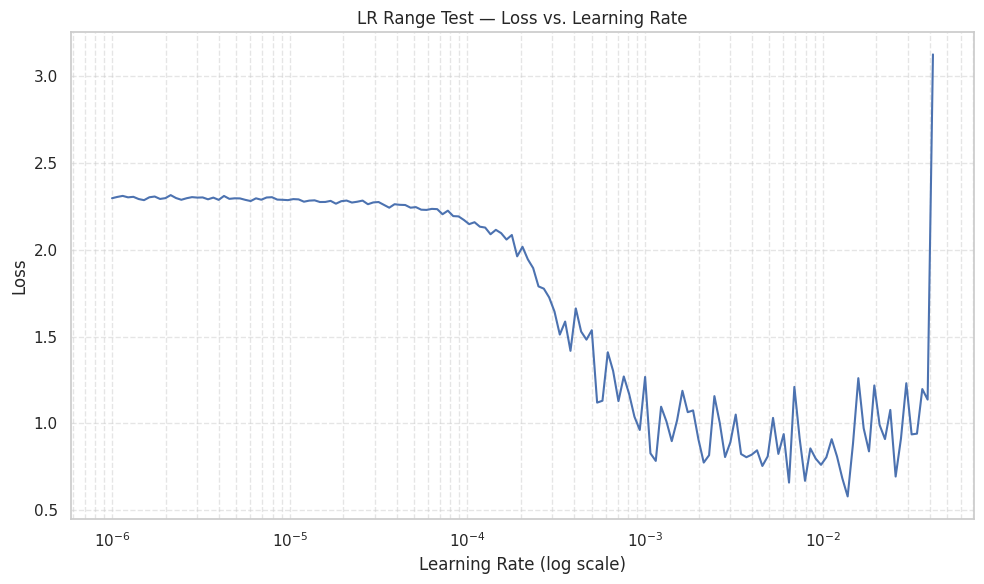

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(lrs, losses)
ax.set_xscale("log")
ax.set_xlabel("Learning Rate (log scale)")
ax.set_ylabel("Loss")
ax.set_title("LR Range Test — Loss vs. Learning Rate")
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Interpreting the plot

Look for the region where the loss drops most steeply. The **optimal starting LR** is typically in the middle of that steep descent -- not at the very bottom (which is often right before divergence).

A good rule of thumb: pick an LR about 10x smaller than the one where the loss starts to diverge.

In [ ]:
show_todo("Answer the LR Range Test analysis question below")

**DONE:** Based on your LR Range Test plot, what starting learning rate would you recommend for training your CNN on FashionMNIST? Why?

**ANSWER:**

<br>
I would recommend a starting learning rate of 5*10^-3 (0.005) because that is where the loss is decreasing the sharpest.
<br>

In [ ]:
show_section()

---
# Challenges

Overview. 


## Challenge 1: Visualizing What the CNN Learned

A big criticism of neural networks is that they are "black box" models. You can train them, but you can't really understand what they learned. In this challenge, you will visualize what the CNN learned by extracting the learned filters and activation maps. This is a key step in understanding the inner workings of a CNN.

How? You can extract the learned filters from the first convolutional layer of the CNN. You can also extract the activation maps from the first convolutional layer of the CNN.
You can then plot the learned filters as images and the activation maps as images.

Dataset: MNIST
Model: CNN

**Your Task:**
Using the MNIST digit dataset:
1. Create a CNN model using your `build_model` function
2. Train a simple CNN model
2. Extract the learned filters from the first convolution layer
3. Plot them as images.
4. Then, select an image from the test set, and plot the activation maps of the first convolutional layer.

**HINTS:**
* Don't use an accelerator device for this challenge.
* You can use the `model.feature_extractor[0].weight.data` attribute to get the learned filters. You can then plot the learned filters as images.
* You can use the `model.feature_extractor[0].forward(input_tensor)` method to get the activation maps. You can then plot the activation maps as images.



In [34]:
from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.utils import build_model, make_optimizer
from src.lantern.trainer import Trainer
from src.lantern.data import get_torchvision_datasets, get_dataloaders

mnist_train_ds, mnist_test_ds = get_torchvision_datasets("mnist")

num_epochs = 15
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 3

trainer_config = TrainerConfig(
    num_epochs=num_epochs,
    device= cpu_device
)

model_config = ModelConfig(
    model_type=ModelType.CNN,
    hidden_units=[128],
    dropout=[0.1],
    conv_blocks=[ConvBlockConfig(8, 3, 1, 1, 2)],
    in_channels=1
)

cnn_model = build_model(input_spec=[28, 28], num_outputs=10, config=model_config)
print(cnn_model)

train_loader, test_loader = get_dataloaders(mnist_train_ds, mnist_test_ds)


trainer = Trainer(model=cnn_model, optimizer=make_optimizer(cnn_model.parameters(), trainer_config), criterion=nn.CrossEntropyLoss(), config=trainer_config)

cnn_results = trainer.fit(train_loader, test_loader)

print(f"CNN Results: {cnn_results}")



100%|██████████| 9.91M/9.91M [00:00<00:00, 21.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 780kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.85MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.55MB/s]

CNN_Model(input=28x28, in_channels=1)
- blocks=[(8, k=3, s=1, p=1)]
- head=[1568 -> [128] -> 10]
- dropout=[0.1]



Epoch 0:
Train Loss=0.3940
Val Loss=0.1408
Train Acc=0.8828
Val Acc=95.63%
Train F1 Macro=0.8813
Val F1 Macro=0.9559
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.1337
Val Loss=0.0849
Train Acc=0.9603
Val Acc=97.21%
Train F1 Macro=0.9600
Val F1 Macro=0.9720
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.0922
Val Loss=0.0655
Train Acc=0.9720
Val Acc=97.89%
Train F1 Macro=0.9717
Val F1 Macro=0.9788
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.0716
Val Loss=0.0629
Train Acc=0.9779
Val Acc=97.91%
Train F1 Macro=0.9778
Val F1 Macro=0.9789
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.0603
Val Loss=0.0562
Train Acc=0.9814
Val Acc=98.19%
Train F1 Macr

In [ ]:
show_todo("Extract the learned filters from the first convolutional layer of the CNN and plot them as images.")

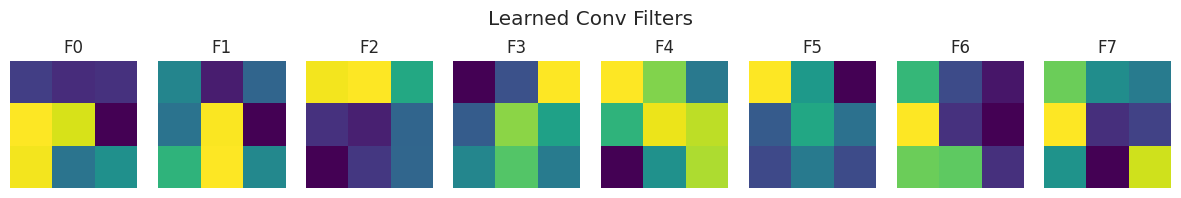

In [35]:
# Plot the learned filters
# feature_extractor[0] is the Conv2d layer
# learned_filters shape: (8, 1, 3, 3) → 8 filters, 1 in_channel, 3x3
learned_filters = cnn_model.feature_extractor[0].weight.data

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
fig.suptitle("Learned Conv Filters")
for i, ax in enumerate(axes):
    ax.imshow(learned_filters[i, 0].cpu().numpy(), cmap="viridis")
    ax.axis("off")
    ax.set_title(f"F{i}")
plt.tight_layout()
plt.show()


In [ ]:
show_todo("Select an image from the dataset and plot the activation maps of the first convolutional layer.")

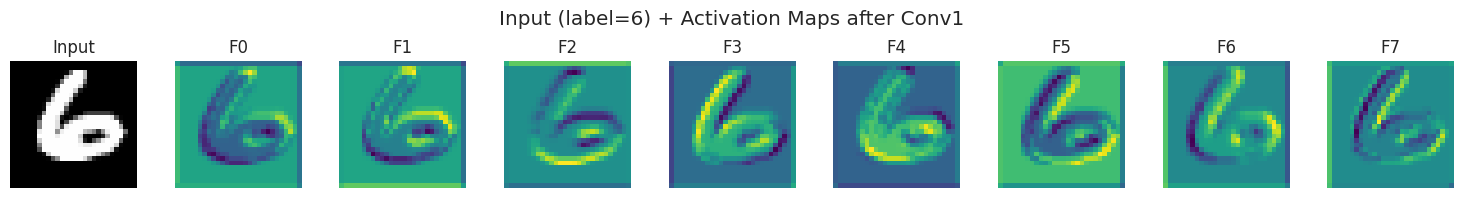

In [36]:
# --- Plot random image and its activation maps ---
# torchvision datasets are indexed like a list → (image, label)
import random
idx = random.randint(0, len(mnist_test_ds) - 1)
random_image, label = mnist_test_ds[idx]  # image shape: (1, 28, 28)

# Conv2d expects (N, C, H, W) so add batch dim
with torch.no_grad():
    activation_maps = cnn_model.feature_extractor[0](
        random_image.unsqueeze(0).to(trainer_config.device)
    )  # shape: (1, 8, 28, 28) — padding=1 preserves size before pooling

activation_maps = activation_maps.squeeze(0)  # (8, 28, 28)

fig, axes = plt.subplots(1, 9, figsize=(15, 2))
fig.suptitle(f"Input (label={label}) + Activation Maps after Conv1")

axes[0].imshow(random_image.squeeze(0).cpu().numpy(), cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")

for i in range(8):
    axes[i + 1].imshow(activation_maps[i].cpu().numpy(), cmap="viridis")
    axes[i + 1].set_title(f"F{i}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

## Challenge 2 - The "Rotation" Stress Test

Convolutional Neural Networks (CNNs) are celebrated for their ability to handle spatial patterns in images and, in particular, their **translation invariance**, meaning, if you move an object around within the frame, the CNN is likely to still recognize it. But there’s a common misconception: many assume CNNs are also **rotation invariant**. In reality, they are not!

Consider this: a human instantly recognizes a digit like "7" whether it’s upright, slightly tilted, or completely rotated—even if you tilt your head, you'll know what it is. Standard CNNs, however, miss this flexibility. Their learned filters are generally sensitive to orientation, making them excel at translations but struggle with rotated versions of the same objects. This is a fundamental limitation in the inductive bias of CNNs. Understanding this helps clarify why certain augmentations and modern architectures are sometimes necessary.

### Revisting the inductive bias of CNNs

We discussed **inductive bias** earlier in this week's homework. It's important. As a reminder in machine learning, inductive bias refers to the set of assumptions a learning algorithm makes to generalize from the training data to unseen data. In other words, it's the "built-in expectations" that guide how a model interprets patterns and makes predictions beyond what it has seen. **Every machine learning algorithm has an inductive bias!** For example, Convolutional Neural Networks (CNNs) assumes local spatial patterns (like edges or simple shapes) are important and that these patterns matter regardless of where they appear in the image (translation invariance). However, CNNs do *not* have a natural bias toward recognizing shapes at arbitrary rotations, which is why our upcoming experiment will show a significant drop in performance when digits are rotated, unless we intervene with strategies like **data augmentation**.

This experiment powerfully illustrates the **inductive bias** of CNNs: they "expect" objects to stay upright and unrotated, unless we explicitly teach them otherwise. **Data augmentation** is a practical solution. In order to get our neural network to recognize our objects in different rotations, we need to For true rotation invariance, researchers explore group convolutions and more advanced architectures—but augmentation is an accessible and effective fix in most practical scenarios.

**Your Task: Testing rotational limits of CNNs, and overcoming them**
1. **Train** your best CNN on standard MNIST digits (no rotations). Use the architecture/configuration from the earlier challenge, tweaking it if necessary to achieve at least **99% validation accuracy** (on unrotated data).
2. **Stress-test Rotation**: Create a new test dataset, where images are randomly rotated with a `transform` that uses `transforms.RandomRotation(degrees=(-90, 90))`. Plot a few of the rotated images. Then, evaluate your model on this rotated data.
3. **Observe the Results**: First, verify that your model still achieves >99% on normal MNIST test data. Then, watch what happens on the rotated data—the accuracy will likely PLUMMET (possibly below 60%). This stark contrast exposes the problem.
4. **Recovery via Data Augmentation**: Retrain your model, but now add random rotations (the same kind you used for the test set) into the **training** dataset as a form of data augmentation. Now, evaluate again on the rotated test set—watch how performance dramatically improves!


**Tips & Hints:**  
- Image transforms are part of the **Dataset** object, not the DataLoader.
- Consider writing a reusable function for loading datasets that allows you to customize the transform pipeline (if you haven't done so already!)
- Try out varying degrees of rotation during augmentation: making the augmentation match the test-time variation is key!
- If you copied your code from the previous solution to get started, be sure you use your `accel_device` in your `TrainerConfig`
- Geometric transforms (rotate, flip, crop) always go before ToTensor(). Pixel-value transforms (normalize, color jitter) always go after.


In [33]:
# DONE: Get your dataset, TrainerConfig and ModelConfig set up.
mnist_train_ds, mnist_test_ds = get_torchvision_datasets("mnist")

num_epochs = 15
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 3

trainer_config = TrainerConfig(
    num_epochs=num_epochs,
    device=accel_device,
)

model_config = ModelConfig(
    model_type=ModelType.CNN,
    hidden_units=[256, 128],
    dropout=[0.3, 0.1],
    conv_blocks=[
        ConvBlockConfig(32, 3, 1, 1, 2),
        ConvBlockConfig(64, 3, 1, 1, 2),
    ],
    in_channels=1
)

train_loader, test_loader = get_dataloaders(mnist_train_ds, mnist_test_ds)

cnn_model = build_model(input_spec=[28, 28], num_outputs=10, config=model_config)
print(cnn_model)
trainer = Trainer(model=cnn_model, optimizer=make_optimizer(cnn_model.parameters(), trainer_config), criterion=nn.CrossEntropyLoss(), config=trainer_config)
cnn_results = trainer.fit(train_loader, test_loader)

print("CNN Model" + str(cnn_model))
print(f"CNN Results: {cnn_results}")

CNN_Model(input=28x28, in_channels=1)
- blocks=[(32, k=3, s=1, p=1), (64, k=3, s=1, p=1)]
- head=[3136 -> [256, 128] -> 10]
- dropout=[0.3, 0.1]

Epoch 0:
Train Loss=0.1917
Val Loss=0.0485
Train Acc=0.9403
Val Acc=98.35%
Train F1 Macro=0.9398
Val F1 Macro=0.9835
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.0578
Val Loss=0.0373
Train Acc=0.9819
Val Acc=98.88%
Train F1 Macro=0.9818
Val F1 Macro=0.9887
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.0427
Val Loss=0.0296
Train Acc=0.9865
Val Acc=99.04%
Train F1 Macro=0.9864
Val F1 Macro=0.9903
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.0335
Val Loss=0.0275
Train Acc=0.9900
Val Acc=99.13%
Train F1 Macro=0.9899
Val F1 Macro=0.9912
--> New best checkpoint saved: ./checkpoints/best.pt


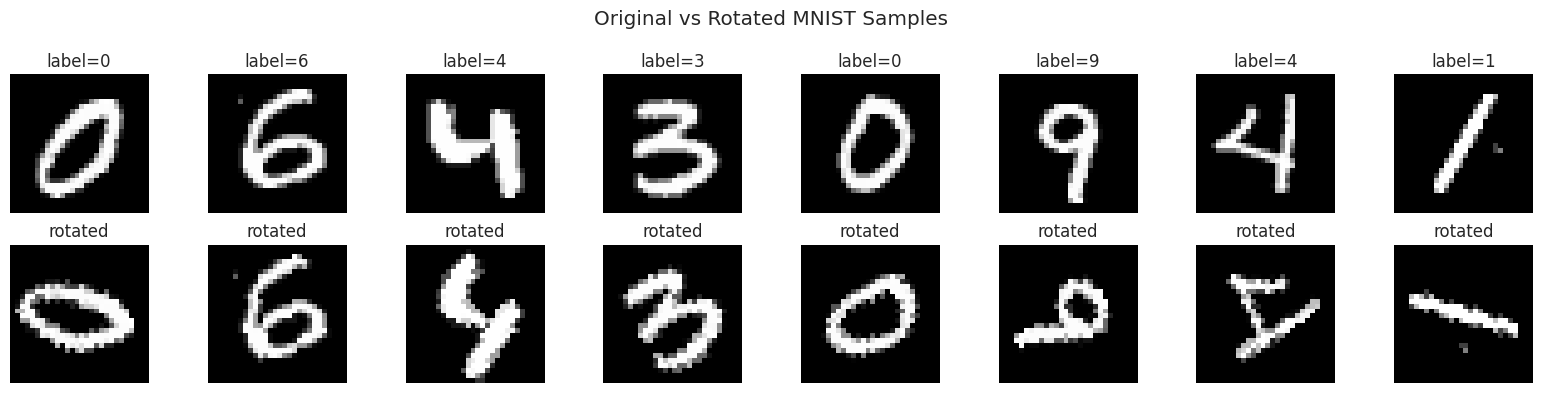


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

(0.034088305606657376, 0.9912, 0.9911239147186279)
(3.313748226928711, 0.5706, 0.5766685009002686)


In [35]:
import random
# Create a new test dataset with random rotations
transform = transforms.Compose([
    transforms.RandomRotation(degrees=(-90, 90)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

rotated_mnist_train_ds,rotated_mnist_test_ds = get_torchvision_datasets("mnist", transform=transform)

rotated_mnist_train_dataloader, rotated_mnist_test_dataloader = get_dataloaders(rotated_mnist_train_ds, rotated_mnist_test_ds)

# --- Plot some random rotated images ---
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Original vs Rotated MNIST Samples")

for i in range(8):
    idx = random.randint(0, len(mnist_test_ds) - 1)
    
    orig_image, label = mnist_test_ds[idx]
    rotated_image, _ = rotated_mnist_test_ds[idx]
    
    axes[0, i].imshow(orig_image.squeeze(0).cpu().numpy(), cmap="gray")
    axes[0, i].set_title(f"label={label}")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(rotated_image.squeeze(0).cpu().numpy(), cmap="gray")
    axes[1, i].set_title(f"rotated")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Rotated", fontsize=12)

plt.tight_layout()
plt.show()

### Show the validation accuracy of original test data and rotated test data on the trained model
print(trainer.validate(test_loader))
print(trainer.validate(rotated_mnist_test_dataloader))


In [36]:
# DONE: Retrain the model with roatated training data and evaluate on the rotated test set.

rot_cnn_model = build_model(input_spec=[28, 28], num_outputs=10, config=model_config)

rot_trainer = Trainer(
    model=rot_cnn_model,
    optimizer=make_optimizer(rot_cnn_model.parameters(), trainer_config),
    criterion=nn.CrossEntropyLoss(),
    config=trainer_config
)

rot_cnn_results = rot_trainer.fit(rotated_mnist_train_dataloader, rotated_mnist_test_dataloader)
# Show the rotated results on your new model
print("Rotated CNN Model" + str(rot_cnn_model))
print(f"Rotated CNN Results: {rot_cnn_results}")

Epoch 0:
Train Loss=0.4561
Val Loss=0.1580
Train Acc=0.8528
Val Acc=95.02%
Train F1 Macro=0.8510
Val F1 Macro=0.9498
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 1:
Train Loss=0.1874
Val Loss=0.1078
Train Acc=0.9430
Val Acc=96.52%
Train F1 Macro=0.9425
Val F1 Macro=0.9649
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 2:
Train Loss=0.1460
Val Loss=0.0897
Train Acc=0.9550
Val Acc=97.25%
Train F1 Macro=0.9546
Val F1 Macro=0.9722
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 3:
Train Loss=0.1290
Val Loss=0.0827
Train Acc=0.9611
Val Acc=97.34%
Train F1 Macro=0.9607
Val F1 Macro=0.9730
--> New best checkpoint saved: ./checkpoints/best.pt
--> Also saving as last checkpoint: ./checkpoints/last.pt
Epoch 4:
Train Loss=0.1145
Val Loss=0.0768
Train Acc=0.9652
Val Acc=97.77%
Train F1 Macr

Final results:

In [37]:
# Evaluate on clean, rotated test set
print('Validation on original test set:')
print(rot_trainer.validate(test_loader))
print('Validation on rotated test set:')
print(rot_trainer.validate(rotated_mnist_test_dataloader))



Validation on original test set:
(0.045005580371618274, 0.9865, 0.986343264579773)
Validation on rotated test set:
(0.056033015742339196, 0.9827, 0.982427179813385)


## Challenge 3: CIFAR-10 Competition

[CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10_) is a dataset assembled from hte Canadian Institute for Advanced Research (CIFAR). It's a collection of 60,000 images over 10 classes, each of which is a 32x32 pixel full color RGB image (i.e. 3 channels).  First made available in 2009, it's been used in hundreds of deep-learning and computer vision research papers. It's much more challenging than the FashionMNIST dataset. The images are actual color photos. And like any photo of an object, you'll have a lot of distractions all around the object you are trying to learn to classify. 

Here's a picture of the first 49 photos in the dataset (courtesy of machinelearningmastery.com):
![CIFAR-10 screenshot](https://machinelearningmastery.com/wp-content/uploads/2019/05/Plot-of-the-First-49-Small-Object-Photographs-From-the-CIFAR10-Dataset.png)

**This is a competition!** Your task is to develop a sweep configuration of CNNs over various hyperparameters to obtain the highest **validation accuracy** on the CIFAR-10 dataset. Like FashionMNIST, it's a balanced dataset over all classes, so `accuracy` is an acceptible measure to maximize.

### Requirements:
* You must use `project = "csci357-hw06-chal03-cifar"` and the class `entity` variable. For example, assuming you nameded your sweep config dictionary `cifar10_sweep_config`:
    ```python
    sweep_id = wandb.sweep(
        entity=entity,
        name="csci357-hw06-chal03-cifar",
        sweep=cifar10_sweep_config,
    )
    ```
* Before you begin, you should plot a random set of 10 images with their labels under the image.
* Develop a comprehensive sweep config dictionary called `cifar10_sweep_config`
* Log the total number of parameters in your model to wandb as `num_parameters`
* Log the trainable number of parameters in your model to wandb as `num_train_parameters` 
* Add your wanb variable `user_initials` so that every run has your initials as a prefix with an `_`
* Please log the names `train_loss`, `train_accuracy`, `val_loss` and `val_accuracy`
* If you are using LR scheduling, be sure you are logging `learning_rate`


HINTS:
* Getting above 80% is challenging, but doable using everything you've learned. 
* Be careful and think about the transforms you pass when you load the datasets. You can do better than just using `ToTensor()` and `Normalize()`. Search for some decent structures. 
* Many will tell you that you need to use `BatchNorm2D` in your convolutional blocks. It's not necessary, as this is still a pretty small dataset, but you are welcome to do so. It should help a bit.
* Be mindful of the channels! These images are color, so they have 3 channels.
* You might want to explore using 

**
https://arxiv.org/html/2404.00498v2



In [36]:
num_epochs = 15
sweep_count = 10
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 40
    sweep_count = 20

cifar10_sweep_config = {
    "method": "bayes",
    "metric": {
        "name": "val_loss",
        "goal": "minimize"
    },
    "parameters": {
        # Fixed parameters
        "evaluator_batch_size": { "value": 256 },
        "num_epochs": {"value": num_epochs},
        "model_type": { "value": "cnn" },
        "in_channels": { "value": 3 },
        "early_stopping_patience": { "value": 5 },

        # Searchable parameters
        "trainer_batch_size": { 
            "values": [128, 256] 
        },
        "learning_rate": {
            "min": 0.0001,
            "max": 0.05,
            "distribution": "log_uniform_values"
        },
        "optimizer_name": { 
            "values": ["adam", "momentum"] 
        },
        "conv_blocks": {
            "values": [                                                                                                                                                                               
                [
                    {"out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                    {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2}
                ],
                [
                    {"out_channels": 32, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                    {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                    {"out_channels": 128, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2}
                ],
                [
                    {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                    {"out_channels": 128, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2}
                ],
                [
                    {"out_channels": 64, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2},
                    {"out_channels": 128, "kernel_size": 3, "stride": 1, "padding": 1, "pool_size": 2}
                ],
            ]
        },
        "hidden_units": {
            "values": [
                [256],
                [256, 128],
                [512, 256],
            ]
        },
        "dropout": {
            "values": [
                [0.3],
                [0.3, 0.1],
                [0.5, 0.3],
            ]
        },
        "weight_decay": {
            "min": 0.00001,
            "max": 0.01,
            "distribution": "log_uniform_values"
        },
        "momentum": {
            "min": 0.8,
            "max": 0.99,
            "distribution": "uniform"
        },
        "scheduler_gamma": {
            "min": 0.3,
            "max": 0.99,
            "distribution": "uniform"
        }
    }
}

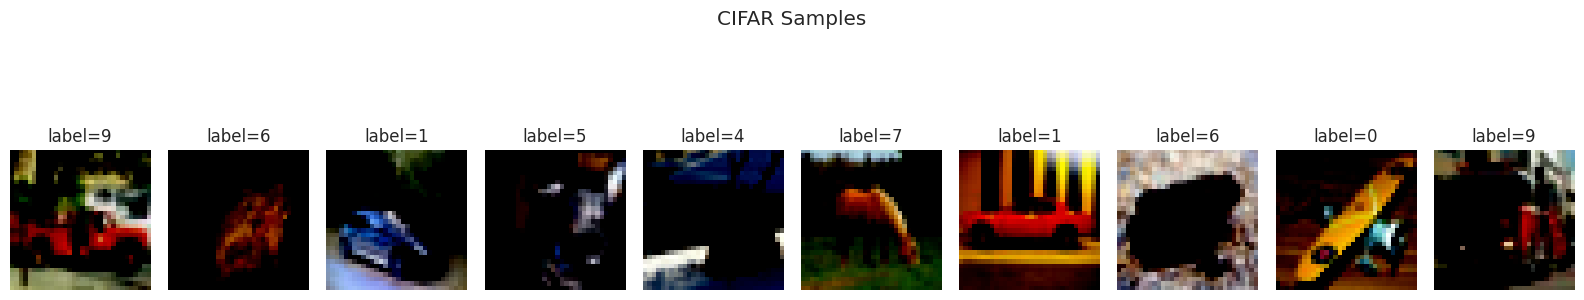

Create sweep with ID: 6cmx7o10
Sweep URL: https://wandb.ai/bucknell-university-csci357-2026sp/csci357-hw06-chal03-cifar/sweeps/6cmx7o10
Sweep 6cmx7o10 has 0 runs
Sweep 6cmx7o10 expected None runs
Sweep 6cmx7o10 current state is: PENDING


wandb: Agent Starting Run: hkopo6he with config:
wandb: 	conv_blocks: [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 128, 'padding': 1, 'pool_size': 2, 'stride': 1}]
wandb: 	dropout: [0.3, 0.1]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [256]
wandb: 	in_channels: 3
wandb: 	learning_rate: 0.00013334082788788546
wandb: 	model_type: cnn
wandb: 	momentum: 0.8175232194453802
wandb: 	num_epochs: 15
wandb: 	optimizer_name: momentum
wandb: 	scheduler_gamma: 0.3618481316482255
wandb: 	trainer_batch_size: 256
wandb: 	weight_decay: 0.0010869249184476603
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb.config: {'conv_blocks': [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 128, 'padding': 1, 'pool_size': 2, 'stride': 1}], 'dropout': [0.3, 0.1], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [256], 'in_channels': 3, 'learning_rate': 0.00013334082788788546, 'model_type': 'cnn', 'momentum': 0.8175232194453802, 'num_epochs': 15, 'optimizer_name': 'momentum', 'scheduler_gamma': 0.3618481316482255, 'trainer_batch_size': 256, 'weight_decay': 0.0010869249184476603}
Run name set to: CMB_cnn_bs256_lr0.00013334082788788546_h256
Epoch 0:
Train Loss=2.2507
Val Loss=2.1595
Train Acc=0.1678
Val Acc=27.76%
Train F1 Macro=0.1606
Val F1 Macro=0.2586
--> New best checkpoint saved: ./checkpoints/csci357-hw06-chal03-cifar-best.pt
--> Also saving as last checkpoint: ./checkpoints/csci357-hw06-chal03-cifar-last.pt
Epoch 1

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▃▅▅▆▆▆▆▇▇▇▇███
train_f1_macro,▁▃▄▅▅▆▆▆▇▇▇▇███
train_loss,█▇▆▅▄▄▃▃▂▂▂▂▁▁▁
val_acc,▁▃▄▄▅▅▆▆▇▇▇▇▇██
val_f1_macro,▁▃▄▄▅▅▆▆▆▇▇▇███
val_loss,█▇▆▅▄▄▃▃▃▂▂▂▁▁▁
epoch,14
train_acc,0.4487
train_f1_macro,0.44347
train_loss,1.53541


Run complete! val_loss: 1.4809 val_acc: 48.13% val_f1_macro: 0.4729


...

Run complete! val_loss: 0.8893 val_acc: 70.66% val_f1_macro: 0.7090


wandb: Agent Starting Run: itcmyfyp with config:
wandb: 	conv_blocks: [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}]
wandb: 	dropout: [0.3, 0.1]
wandb: 	early_stopping_patience: 5
wandb: 	evaluator_batch_size: 256
wandb: 	hidden_units: [256, 128]
wandb: 	in_channels: 3
wandb: 	learning_rate: 0.0007689213011716923
wandb: 	model_type: cnn
wandb: 	momentum: 0.864978265956358
wandb: 	num_epochs: 15
wandb: 	optimizer_name: adam
wandb: 	scheduler_gamma: 0.5467045317395856
wandb: 	trainer_batch_size: 128
wandb: 	weight_decay: 2.6231709044681696e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Ctrl + C detected. Stopping sweep.



✓ Sweep complete! All runs finished.



wandb.config: {'conv_blocks': [{'kernel_size': 3, 'out_channels': 32, 'padding': 1, 'pool_size': 2, 'stride': 1}, {'kernel_size': 3, 'out_channels': 64, 'padding': 1, 'pool_size': 2, 'stride': 1}], 'dropout': [0.3, 0.1], 'early_stopping_patience': 5, 'evaluator_batch_size': 256, 'hidden_units': [256, 128], 'in_channels': 3, 'learning_rate': 0.0007689213011716923, 'model_type': 'cnn', 'momentum': 0.864978265956358, 'num_epochs': 15, 'optimizer_name': 'adam', 'scheduler_gamma': 0.5467045317395856, 'trainer_batch_size': 128, 'weight_decay': 2.6231709044681696e-05}
Run name set to: CMB_cnn_bs128_lr0.0007689213011716923_h256x128


In [ ]:
import random
from src.lantern.sweep import make_train_sweep
project = "csci357-hw06-chal03-cifar"
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
    (0.5, 0.5, 0.5),
    (0.5, 0.5, 0.5)
    )
])
cifar10_train_ds, cifar10_test_ds = get_torchvision_datasets("cifar10", transform=transform)
datasets = (cifar10_train_ds, cifar10_test_ds)
input_spec = [32, 32]
num_outputs = 10

# --- Plot 10 random CIFAR images ---
fig, axes = plt.subplots(1, 10, figsize=(16, 4))
fig.suptitle("CIFAR Samples")

for i in range(10):
    idx = random.randint(0, len(cifar10_test_ds) - 1)
    
    orig_image, label = cifar10_test_ds[idx]
    
    axes[i].imshow(orig_image.permute(1, 2, 0).cpu().numpy())
    axes[i].set_title(f"label={label}")
    axes[i].axis("off")

axes[0].set_ylabel("Original", fontsize=12)

plt.tight_layout()
plt.show()

train_sweep = make_train_sweep(
    wandb_project_name=project,
    wandb_entity_name=entity,
    wandb_name_prefix=user_initials,
    datasets=datasets,
    device=accel_device,
    input_spec=input_spec,
    num_outputs=num_outputs,
)

from src.lantern.sweep import print_sweep_info, terminate_sweep

sweep_id = wandb.sweep(
    entity=entity,
    sweep=cifar10_sweep_config,
    project=project
)
print_sweep_info(sweep_id)

wandb.agent(sweep_id=sweep_id, function=train_sweep, count=sweep_count)

print("\n" + "="*60)
print("✓ Sweep complete! All runs finished.")
print("\n" + "="*60)

print_sweep_info(sweep_id)
terminate_sweep(sweep_id)

# Career Survey

First, let's start with a recent article from LinkedIn that appeared at the start of the year: 
* https://www.linkedin.com/pulse/linkedin-jobs-rise-2026-25-fastest-growing-roles-us-linkedin-news-dlb1c/

That's your positive news for the day.

Now, back to reality. The focus for this reflection is about the job market. This is actually one of the better posts on the topic. It appeared on the site Extern on Feb 12, 2026. 

**READ THE FOLLOWING ARTICLE:**<br>
https://www.extern.com/post/computer-science-job-market-2026-guide 

## DONE
Choose one of the following prompts and write a 150-200 word response in your own words.

1. The article identifies a "hidden" job market - mid-size companies, startups, government tech, and non-profit organizations - as more accessible entry points than Big Tech for new CS grads. It also highlights non-coding roles like product management, data analytics, and technical sales as viable paths. Reflecting on your own career goals, was this change some of your short term considerations for the types of jobs you might search for? How open are you to starting in a role or organization that falls outside your original expectations? What factors would most influence your willingness to consider different roles you didn't consider before?

**ANSWER:**
<br>
<br>


2. The article argues that the skills most resistant to AI displacement are system thinking, problem decomposition, communication, and user empathy — not coding itself. Yet, it must feel at times that the vast majority of your entire degree has been measured largely through code? Hopefully it's not that one-sided! But, do you feel your education (in and out of CSCI) has adequately prepared you in these "meta-skills"? What experiences — inside or outside the classroom — have developed them most for you?

**ANSWER:**
<br>
I would argue that my education has been somewhat helpful in helping me develop these "meta-skills". However, I would also argue that most of the skills that I learned that are "AI-resistant" come from my own efforts in learning outside of the classroom. They are of my own volition. I believe that the experiences that have helped me developed these skills the most is my entrepreneurial ventures. Trying to create a startup has forced me to practice skills that I would have otherwised ignored, such as understanding users and knowing how to build something from scratch without any assistance. My internship and work experience have also been invaluable as these environments force me to think how to build at scale and not just create a minimal MVP that works locally. However, I still think that knowing how to code at a basic level is still fundamental as a CS student. You can't perform well if you don't know how to code at all.
<br>


3. The article draws a sharp distinction between workers who "direct AI tools" and those who are "made redundant by them." Having studied how neural networks and AI systems actually work under the hood, where do you honestly place yourself on that spectrum right now — and what would it concretely take to move further toward the "directing" side before you graduate?

**ANSWER:**
<br>
<br>



# Society

Every few decades, a technology arrives that doesn't just change *how* we work — it changes *who* does the work, and whether certain jobs exist at all. There is no doubt in anyone's mind that we are indeed living through one of those moments right now. The AI systems you are studying in this course are no longer confined to classrooms and research labs; they are actively being deployed. Companies competing to one-up each other with AI capabilities every few months, now pushing more agentic capabilities to autonomously handle tasks that, until very recently, required years of expensive professional training. (Law and software development come to mind!) The question is no longer whether AI will reshape white-collar work — it already is. The question is *how*, *how fast*, and *what it means*.

Last week, on Feb 17, 2026, the editorial team at *The Washington Post* published a short op-ed titled, ["What AI is really coming for"](https://www.washingtonpost.com/opinions/2026/02/17/anthropic-lawyers-technology/). It mostly focuses on the big impact of Anthropic's agentic capabilities demonstrated on the legal profession. The article suggests that AI's disruption on certain professions like law should be something to fear, but something to welcome. It reflects on some historical analogies and economic reasoning, to conclude that this is not a catastrophe, but more of a long-overdue correction.

Read it carefully. It's short. Many of you may be going into the field of AI directly, not just observers or users of AI tools, but active practitioners. Read this piece carefully and critically, paying attention not only to the arguments being made, but to the assumptions buried underneath them. The reflection questions that follow are designed to help you connect the author's claims to the technical realities you are learning in your own readings and ponderings about your future, and even things you are learning in this course.

## **DONE**

Read the article, then choose TWO of the four questions below that speak to you the most. Reflect and offer your own thoughtful, critical take on the prompt. No more than 1-2 paragraphs required for each.

### Questions

**1. The article argues that AI follows the same historical pattern as ATMs and mechanical looms — automating tasks without eliminating net jobs. Do you find this analogy convincing for modern AI agents, or does the cognitive nature of what AI automates make it fundamentally different from prior technological disruptions? Justify your position with technical reasoning.**

**ANSWER:**
<br>
I would argue that this analogy somewhat applies to AI agents, but it is more nuanced than those examples. AI agents are probabilistic models, which means that we cannot accurately predict its outputs and actions. Meanwhile, ATMs and mechanical looms are deterministic machines. This makes it difficult to say that AI agents will have the same effect on society as the latter innovations have. However, we are increasingly seeing that AI agents are not as capable as we thought of them to be. For instance, it still has limitations on being able to understand mathematical theory on a deeper level. If anything, it is like a probabilistic calculator that people can use to quickly check their work and find new directions to explore.
<br>

**2. The editorial claims "what computers best automate is drudgery." As someone studying neural networks, do you agree with this framing? What kinds of tasks are *technically hardest* for AI to automate, and does the article's optimism account for those limitations?**

**ANSWER:**
<br>
Yes, I agree with this framing. Computers (and AI) are excellent at automating redundant and repetitive tasks that have clear instructions. That's what makes coding so useful. It abstracts a lot of the manual tasks and makes computers run them for us. With AI, we unlock more capability by allowing it to understand more context without us having to tell exactly what to do. However, it still does not perform well in environments that it has not seen (trained on) before. Humans are good at adapting to these unknown scenarios. The article's optimism sort of accounts for these by arguing that AI is good for automating mundane tasks, a lot of which have been recorded by humans in recent history.
<br>


**3. Anthropic's AI agents can autonomously execute legal research and compliance workflows. Where, technically, does autonomous AI agency end and human judgment begin? Is that boundary fixed, or does it shift as models improve? What are the implications if it keeps shifting?**

**ANSWER:**
<br>
<br>


**4. The op-ed frames the reduction of lawyers as a net positive, freeing talent for "other pursuits." But who decides which professions get disrupted and in what order? Are there ethical responsibilities embedded in the *design choices* made by AI developers like Anthropic that the article overlooks?**

**ANSWER:**
<br>
<br>




# AI Usage Disclosure

**IDE or browser-based environment used:** VSCode

**AI tools used:** Claude

**Short reflection:**
How did you use AI this week? Did it help you understand activation functions? Debug your training loop? Explain backpropagation? Be specific about what worked well and what didn't.

I used Claude to explain the concepts.

**AI Chat Dialogs:**
(Paste relevant snippets here - particularly any that helped you understand conceptual questions or debug code)
<br/>
1.
```
what is padding and out channels8:35 PMout_channels
Each filter is a small 3D tensor (shape: in_channels × kH × kW) that slides over the input and produces one 2D feature map as output. out_channels is simply how many of these filters you want to learn.
Input: (1, 28, 28)  →  apply 16 filters  →  Output: (16, 26, 26)
         ↑                                              ↑
    1 channel                                    16 feature maps
Each filter learns to detect something different — edges, curves, textures, etc. You're essentially asking: "how many distinct patterns do I want to detect?"

padding
Without padding, every time you apply a kernel, the output shrinks. A 3×3 kernel on a 28×28 image gives a 26×26 output — you lose 1 pixel on each side.
Padding adds a border of zeros around the input before convolving, so the kernel has room to "hang off" the edges.
padding=0 (default):   28x28 → 26x26   (shrinks)
padding=1:             28x28 → 28x28   (preserved)
Visually for a 1D case:
No padding:   [1, 2, 3, 4, 5]          kernel slides 3 times → 3 outputs
With padding: [0, 1, 2, 3, 4, 5, 0]   kernel slides 5 times → 5 outputs
The reason you care: in deep networks, if every layer shrinks the input, you run out of spatial resolution quickly. padding=1 with a 3×3 kernel is the standard fix to preserve size across layers.
```

2.
```
Can you finish up the plotting code:

from src.lantern.config import TrainerConfig, ModelConfig, ConvBlockConfig
from src.lantern.utils import build_model, make_optimizer
from src.lantern.trainer import Trainer
from src.lantern.data import get_torchvision_datasets, get_dataloaders

mnist_train_ds, mnist_test_ds = get_torchvision_datasets("mnist")

num_epochs = 15
if RUN_TRAINING_MODE != RunTrainingMode.FULL:
    num_epochs = 3

trainer_config = TrainerConfig(
    num_epochs=num_epochs,
    device= cpu_device
)

model_config = ModelConfig(
    model_type=ModelType.CNN,
    hidden_units=[128],
    dropout=[0.1],
    conv_blocks=[ConvBlockConfig(8, 3, 1, 1, 2)],
    in_channels=1
)

cnn_model = build_model(input_spec=[28, 28], num_outputs=10, config=model_config)
print(cnn_model)

train_loader, test_loader = get_dataloaders(mnist_train_ds, mnist_test_ds)


trainer = Trainer(model=cnn_model, optimizer=make_optimizer(cnn_model.parameters(), trainer_config), criterion=nn.CrossEntropyLoss(), config=trainer_config)

cnn_results = trainer.fit(train_loader, test_loader)

print(f"CNN Results: {cnn_results}")



learned_filters = cnn_model.feature_extractor[0].weight.data

# Plot the learned filters



random_image = mnist_test_ds.sample()
activation_maps = cnn_model.feature_extractor[0].forward(random_image)

# Plot the random image and activation maps

There's no sample() method on torchvision datasets — you just index them directly. Here's the corrected plotting code:
pythonimport matplotlib.pyplot as plt
import torch

# --- Plot learned filters ---
# feature_extractor[0] is the Conv2d layer
# learned_filters shape: (8, 1, 3, 3) → 8 filters, 1 in_channel, 3x3
learned_filters = cnn_model.feature_extractor[0].weight.data

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
fig.suptitle("Learned Conv Filters")
for i, ax in enumerate(axes):
    ax.imshow(learned_filters[i, 0].cpu().numpy(), cmap="viridis")
    ax.axis("off")
    ax.set_title(f"F{i}")
plt.tight_layout()
plt.show()

# --- Plot random image and its activation maps ---
# torchvision datasets are indexed like a list → (image, label)
import random
idx = random.randint(0, len(mnist_test_ds) - 1)
random_image, label = mnist_test_ds[idx]  # image shape: (1, 28, 28)

# Conv2d expects (N, C, H, W) so add batch dim
with torch.no_grad():
    activation_maps = cnn_model.feature_extractor[0](
        random_image.unsqueeze(0).to(trainer_config.device)
    )  # shape: (1, 8, 28, 28) — padding=1 preserves size before pooling

activation_maps = activation_maps.squeeze(0)  # (8, 28, 28)

fig, axes = plt.subplots(1, 9, figsize=(15, 2))
fig.suptitle(f"Input (label={label}) + Activation Maps after Conv1")

axes[0].imshow(random_image.squeeze(0).cpu().numpy(), cmap="gray")
axes[0].set_title("Input")
axes[0].axis("off")

for i in range(8):
    axes[i + 1].imshow(activation_maps[i].cpu().numpy(), cmap="viridis")
    axes[i + 1].set_title(f"F{i}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()
```

# Clean shutdown for Colab

In [ ]:
# Disconnect the runtime if in Colab
if IN_COLAB:
    from google.colab import runtime
    print("Disconnecting runtime...")
    runtime.unassign()
else:
    print("Not running in Colab, skipping disconnect.")